In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]  # adjust if your cwd differs
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.run_pd_experiments import run_single_experiment
from empathy.prisoners_dilemma.tom import TheoryOfMind, SocialEFE, OpponentInversion
from empathy.prisoners_dilemma.tom.inversion import ObservationContext, GatedToM
from empathy.prisoners_dilemma.tom.tom_core import softmax as tom_softmax

In [3]:
import matplotlib.pyplot as plt
import numpy as np

[array([0.25, 0.25, 0.25, 0.25])]
[array([0.06666667, 0.06666667, 0.06666667, 0.06666667])]
[array([0.8       , 0.06666667, 0.06666667, 0.06666667])]


/home/aljiro/miniconda-empathy/envs/empathy-prisoner-dilemma/lib/python3.11/site-packages/pymdp/maths.py:284: RuntimeWarning: invalid value encountered in log
  return np.log(arr + EPS_VAL)


[array([0.25, 0.25, 0.25, 0.25])]
[array([0.06666667, 0.06666667, 0.06666667, 0.06666667])]
[array([0.8       , 0.06666667, 0.06666667, 0.06666667])]


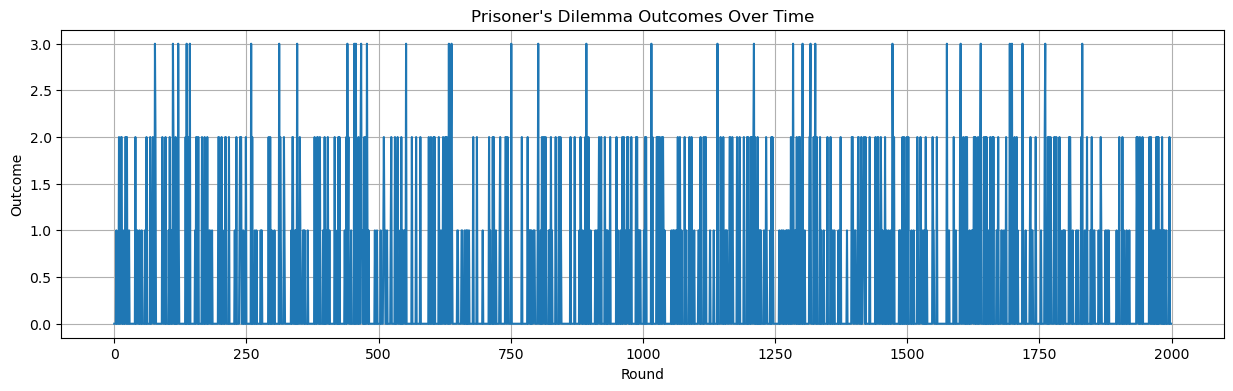

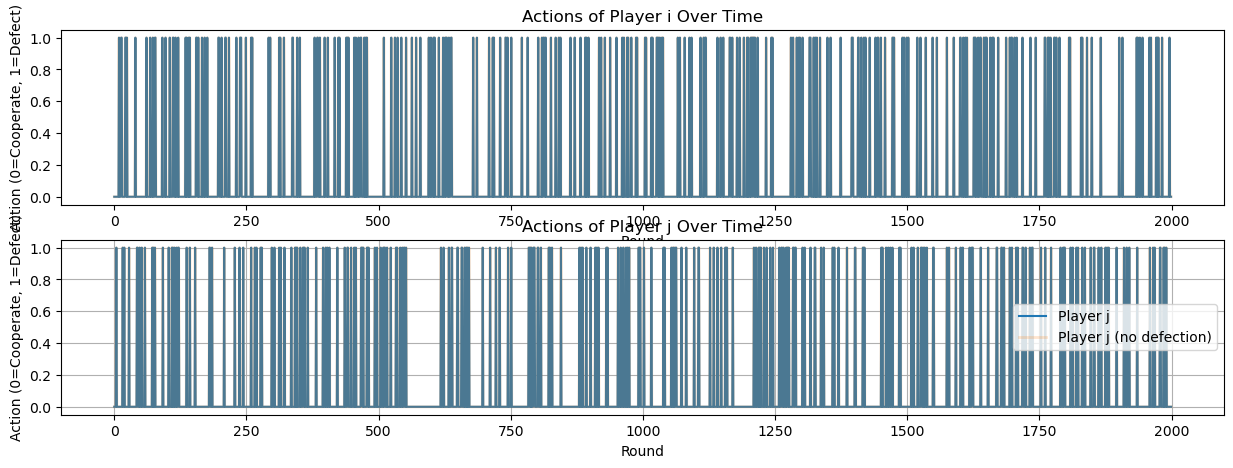

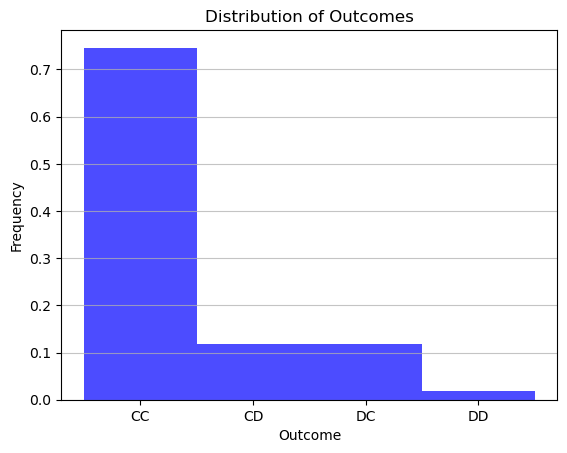

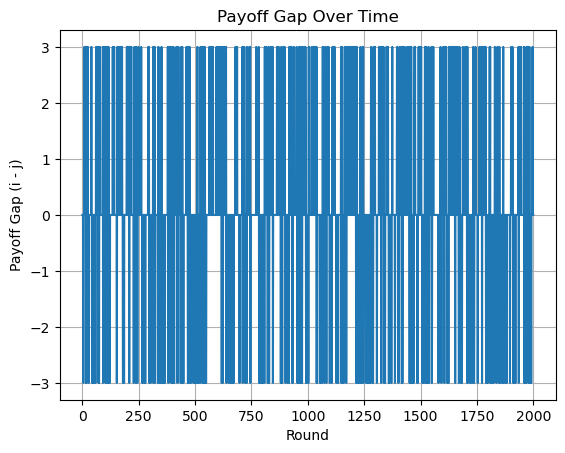

Average Payoff Gap: -0.0015


In [4]:
lambda_i = 0.7
lambda_j = 0.7
beta_i = 0.8
beta_j = 0.8
T = 2000

res_base = run_single_experiment(lambda_i, lambda_j, T=T, defect_interval=(0, -300), beta_i=beta_i, beta_j=beta_j, use_inversion=True )
outcomes_base = res_base.outcomes
actions_i_base = res_base.actions_i
actions_j_base = res_base.actions_j 
payoff_gap_base = res_base.payoffs_i - res_base.payoffs_j

res = run_single_experiment(lambda_i, lambda_j, T=T, defect_interval=(0, 300), beta_i=beta_i, beta_j=beta_j, use_inversion=True )
outcomes = res.outcomes  
actions_i = res.actions_i
actions_j = res.actions_j
payoff_gap = res.payoffs_i - res.payoffs_j

plt.figure(figsize=(15, 4))
plt.plot(outcomes)
plt.xlabel("Round")
plt.ylabel("Outcome")
plt.title("Prisoner's Dilemma Outcomes Over Time")
plt.grid()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(15, 5))

ax[0].plot(actions_i, label="Player i")
ax[0].plot(actions_i_base, label="Player i (no defection)", linewidth = 2.0, alpha = 0.2)
ax[1].plot(actions_j, label="Player j")
ax[1].plot(actions_j_base, label="Player j (no defection)", linewidth = 2.0, alpha = 0.2)
ax[0].set_xlabel("Round")
ax[1].set_xlabel("Round")
ax[0].set_ylabel("Action (0=Cooperate, 1=Defect)")
ax[1].set_ylabel("Action (0=Cooperate, 1=Defect)")
ax[0].set_title("Actions of Player i Over Time")
ax[1].set_title("Actions of Player j Over Time")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.hist(outcomes, bins=np.arange(-0.5, 4.5, 1), density=True, alpha=0.7, color='blue')
plt.xlabel("Outcome")
plt.ylabel("Frequency")
plt.title("Distribution of Outcomes")
plt.xticks([0, 1, 2, 3], ["CC", "CD", "DC", "DD"])
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure()
plt.plot(payoff_gap)
plt.xlabel("Round")
plt.ylabel("Payoff Gap (i - j)")
plt.title("Payoff Gap Over Time")
plt.grid()
plt.show()

print("Average Payoff Gap:", np.mean(payoff_gap))

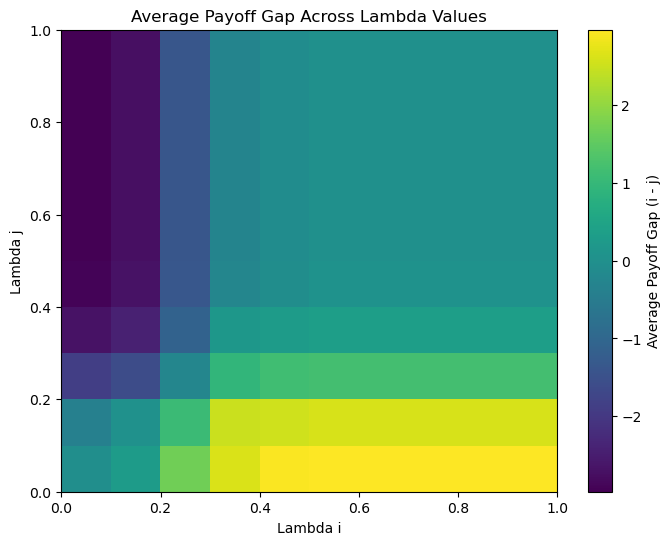

In [4]:
lambda_i = np.linspace(0, 1, 10)
lambda_j = np.linspace(0, 1, 10)

payoff_gaps = np.zeros((len(lambda_i), len(lambda_j)))
for i, li in enumerate(lambda_i):
    for j, lj in enumerate(lambda_j):
        res = run_single_experiment(li, lj, T=100)
        payoff_gaps[i, j] = np.mean(res.payoffs_i - res.payoffs_j)
        
plt.figure(figsize=(8, 6))
plt.imshow(payoff_gaps, extent=(0, 1, 0, 1), origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Average Payoff Gap (i - j)')
plt.xlabel('Lambda i')
plt.ylabel('Lambda j')
plt.title('Average Payoff Gap Across Lambda Values')
plt.show()

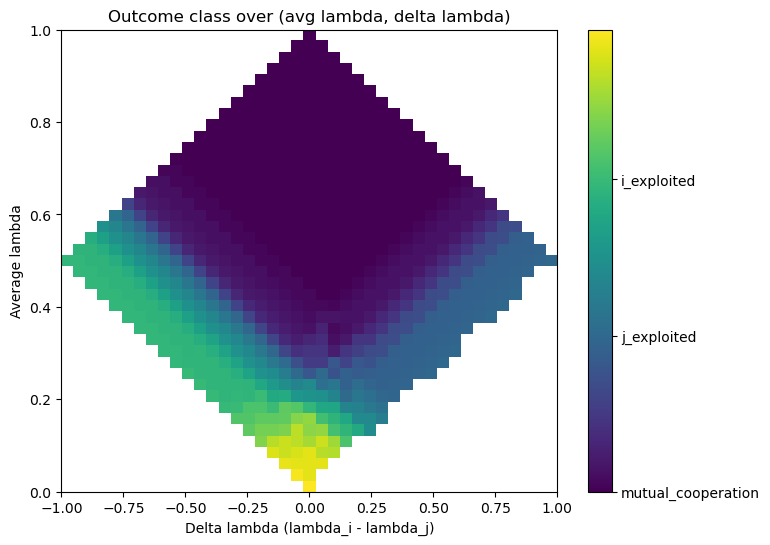

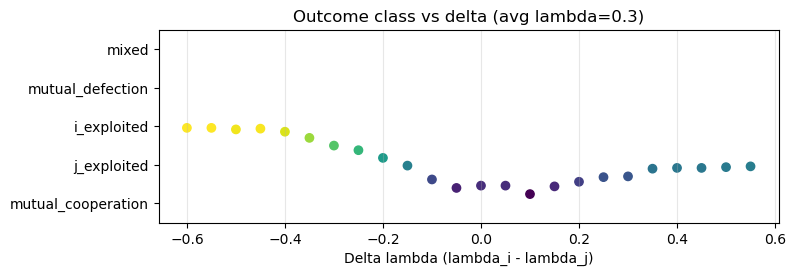

In [5]:
from matplotlib import colors

# Grid over average empathy and delta (lambda_i - lambda_j).
n_avg = 41
n_delta = 41
avg_vals = np.linspace(0.0, 1.0, n_avg)
delta_vals = np.linspace(-1.0, 1.0, n_delta)

# Map outcome labels to integers for a discrete color plot.
outcome_map = {
    "mutual_cooperation": 0,
    "j_exploited": 1,
    "i_exploited": 2,
    "mutual_defection": 3,
    "mixed": 4,
}
outcome_labels = [
    "mutual_cooperation",
    "j_exploited",
    "i_exploited",
    "mutual_defection",
    "mixed",
]

grid = np.full((n_avg, n_delta), np.nan)

for a_idx, avg_lambda in enumerate(avg_vals):
    for d_idx, delta in enumerate(delta_vals):
        lambda_i = avg_lambda + 0.5 * delta
        lambda_j = avg_lambda - 0.5 * delta
        if lambda_i < 0 or lambda_i > 1 or lambda_j < 0 or lambda_j > 1:
            continue
        res = run_single_experiment(lambda_i, lambda_j, T=50, seed=0)
        grid[a_idx, d_idx] = np.mean(res.outcomes)  # Use numeric outcomes for the grid

cmap = colors.ListedColormap(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#7f7f7f"])
bounds = np.arange(-0.5, len(outcome_labels) + 0.5, 1)
norm = colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8, 6))
plt.imshow(
    grid,
    extent=(delta_vals[0], delta_vals[-1], avg_vals[0], avg_vals[-1]),
    origin="lower",
    aspect="auto",
    interpolation="nearest",
)
cbar = plt.colorbar(ticks=np.arange(len(outcome_labels)))
cbar.ax.set_yticklabels(outcome_labels)
plt.xlabel("Delta lambda (lambda_i - lambda_j)")
plt.ylabel("Average lambda")
plt.title("Outcome class over (avg lambda, delta lambda)")
plt.show()

# 1D slice: fix average empathy and sweep delta.
avg_lambda = 0.3
delta_vals_1d = np.linspace(-1.0, 1.0, 41)
outcome_1d = []
for delta in delta_vals_1d:
    lambda_i = avg_lambda + 0.5 * delta
    lambda_j = avg_lambda - 0.5 * delta
    if lambda_i < 0 or lambda_i > 1 or lambda_j < 0 or lambda_j > 1:
        outcome_1d.append(np.nan)
        continue
    res = run_single_experiment(lambda_i, lambda_j, T=50, seed=0)
    outcome_1d.append(np.mean(res.outcomes))  # Use numeric outcomes for scatter plot

plt.figure(figsize=(8, 2.5))
plt.scatter(delta_vals_1d, outcome_1d, c=outcome_1d)
plt.yticks(np.arange(len(outcome_labels)), outcome_labels)
plt.xlabel("Delta lambda (lambda_i - lambda_j)")
plt.title(f"Outcome class vs delta (avg lambda={avg_lambda})")
plt.ylim(-0.5, len(outcome_labels) - 0.5)
plt.grid(axis="x", alpha=0.3)
plt.show()

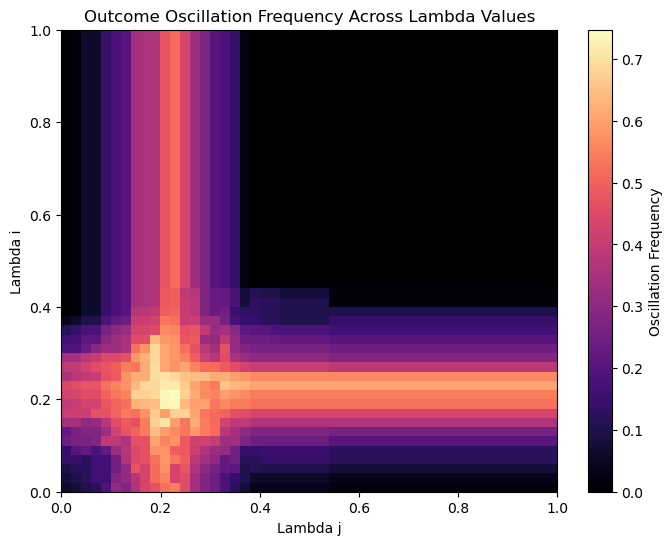

In [6]:
# Heatmap of oscillation frequency: fraction of rounds where outcome changes
lambda_vals = np.linspace(0, 1, 50)
oscillation_freq = np.zeros((len(lambda_vals), len(lambda_vals)))

for i, li in enumerate(lambda_vals):
    for j, lj in enumerate(lambda_vals):
        res = run_single_experiment(li, lj, T=100, seed=0)
        outcomes_arr = np.asarray(res.outcomes)
        oscillation_freq[i, j] = np.mean(outcomes_arr[1:] != outcomes_arr[:-1])

plt.figure(figsize=(8, 6))
plt.imshow(
    oscillation_freq,
    extent=(0, 1, 0, 1),
    origin="lower",
    aspect="auto",
    cmap="magma",
)
plt.colorbar(label="Oscillation Frequency")
plt.xlabel("Lambda j")
plt.ylabel("Lambda i")
plt.title("Outcome Oscillation Frequency Across Lambda Values")
plt.show()

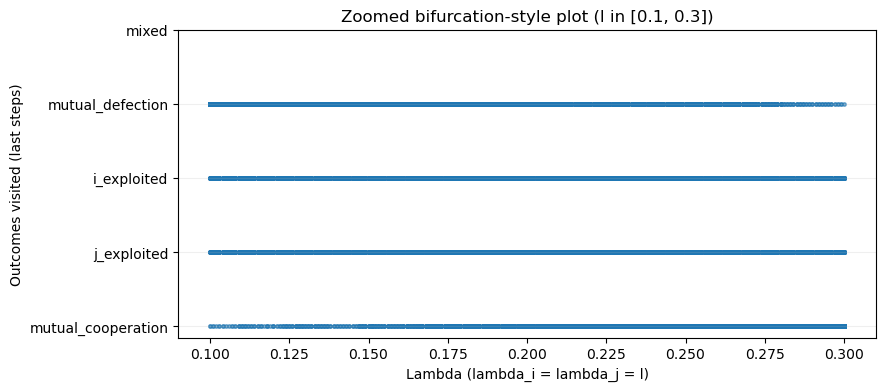

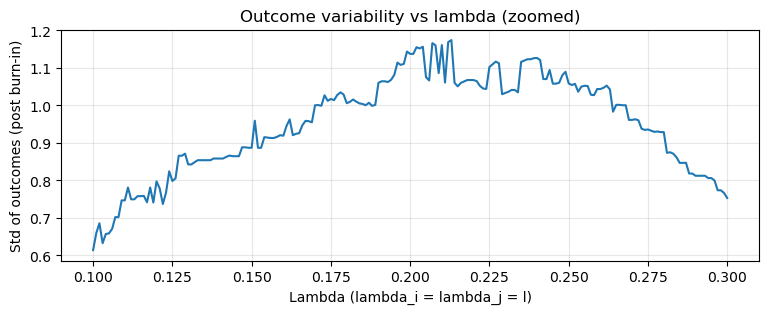

In [7]:
l_vals_zoom = np.linspace(0.1, 0.3, 201)
T_zoom = 500
burn_in_zoom = 300

xs_zoom = []
ys_zoom = []

for l in l_vals_zoom:
    res = run_single_experiment(l, l, T=T_zoom, seed=0)
    tail = np.asarray(res.outcomes[burn_in_zoom:], dtype=float)
    xs_zoom.extend([l] * len(tail))
    ys_zoom.extend(tail)

plt.figure(figsize=(9, 4))
plt.scatter(xs_zoom, ys_zoom, s=6, alpha=0.35)
plt.yticks(np.arange(len(outcome_labels)), outcome_labels)
plt.xlabel("Lambda (lambda_i = lambda_j = l)")
plt.ylabel("Outcomes visited (last steps)")
plt.title("Zoomed bifurcation-style plot (l in [0.1, 0.3])")
plt.grid(axis="y", alpha=0.2)
plt.show()

# Variability across l: higher variance can indicate chaotic-like behavior
variability = []
for l in l_vals_zoom:
    res = run_single_experiment(l, l, T=T_zoom, seed=0)
    tail = np.asarray(res.outcomes[burn_in_zoom:], dtype=float)
    variability.append(np.nanstd(tail))

plt.figure(figsize=(9, 3))
plt.plot(l_vals_zoom, variability)
plt.xlabel("Lambda (lambda_i = lambda_j = l)")
plt.ylabel("Std of outcomes (post burn-in)")
plt.title("Outcome variability vs lambda (zoomed)")
plt.grid(alpha=0.3)
plt.show()

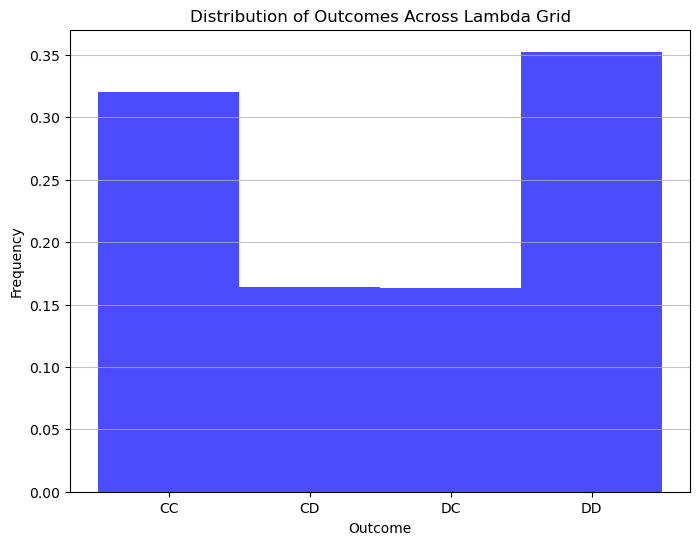

In [122]:
lambda_grid = np.linspace(0.1, 0.3, 21)
outcome_variability = np.zeros((len(lambda_grid), len(lambda_grid)))

all_outcomes = []
for j in range(20):
    for i, li in enumerate(lambda_grid):
        res = run_single_experiment(li, li, T=400, seed=np.random.randint(100000), beta_i = 5, beta_j=5)
            
        all_outcomes.append(res.outcomes)

plt.figure(figsize=(8, 6))
plt.hist(np.concatenate(all_outcomes), bins=np.arange(-0.5, 4.5, 1), density=True, alpha=0.7, color='blue')
plt.xlabel("Outcome")
plt.ylabel("Frequency")
plt.title("Distribution of Outcomes Across Lambda Grid")
plt.xticks([0, 1, 2, 3], ["CC", "CD", "DC", "DD"])
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
lambda_grid = np.linspace(0, 1, 21)
outcome_variability = np.zeros((len(lambda_grid), len(lambda_grid)))

for i, li in enumerate(lambda_grid):
    for j, lj in enumerate(lambda_grid):
        res = run_single_experiment(li, lj, T=200, seed=np.random.randint(100000), beta_i = 5, beta_j=5)
        outcome_variability[i, j] = np.nanstd(np.asarray(res.outcomes, dtype=float))

plt.figure(figsize=(8, 6))
plt.imshow(
    outcome_variability,
    extent=(0, 1, 0, 1),
    origin="lower",
    aspect="auto",
    cmap="plasma",
)
plt.colorbar(label="Std of Outcomes")
plt.xlabel("Lambda j")
plt.ylabel("Lambda i")
plt.title("Outcome Variability Across Lambda Values")
plt.show()

Final figure

/tmp/ipykernel_74892/3377912966.py:75: RuntimeWarning: invalid value encountered in divide
  pD = (k + alpha) / (n + 2*alpha)
/tmp/ipykernel_74892/3377912966.py:194: RuntimeWarning: All-NaN slice encountered
  mem2_list_max = np.nanmax(np.vstack([mem2_list_C, mem2_list_D]), axis=0)
/tmp/ipykernel_74892/3377912966.py:195: RuntimeWarning: Mean of empty slice
  mem_max_by_l.append(np.nanmean(mem2_list_max))
/home/aljiro/miniconda-empathy/envs/empathy-prisoner-dilemma/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


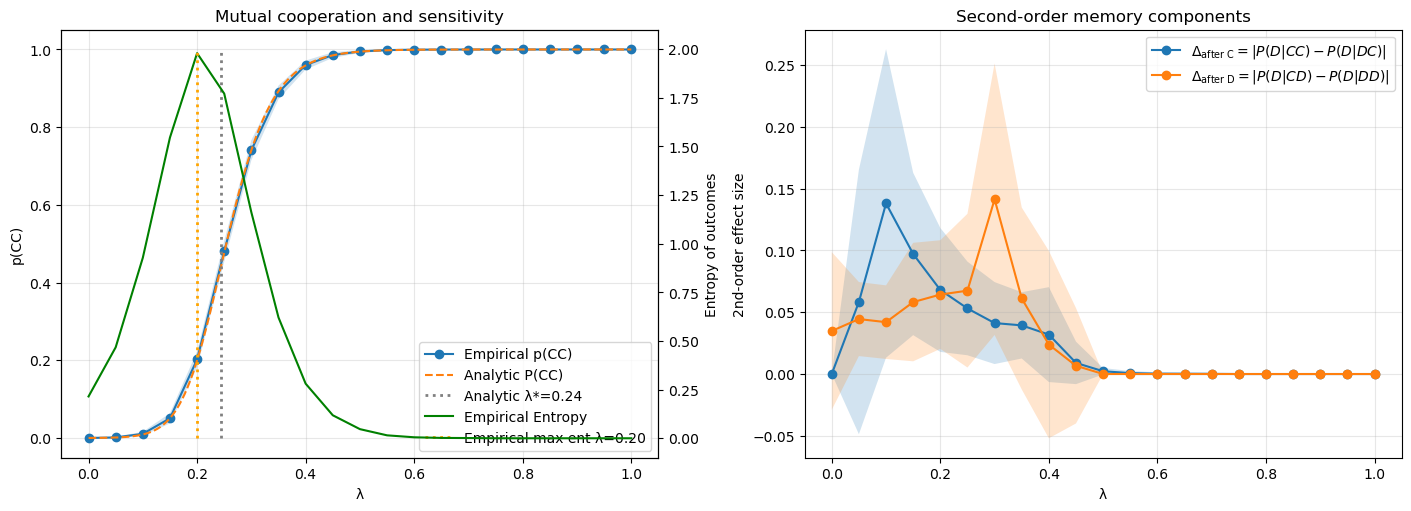

In [35]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["CC", "CD", "DC", "DD"]
n_states = len(labels)

def _outcome_entropy(outcomes):
    counts = np.bincount(outcomes, minlength=n_states).astype(float)
    probs = counts / np.maximum(counts.sum(), 1.0)
    mask = probs > 0
    return -np.sum(probs[mask] * np.log2(probs[mask]))

def _switching_rate(outcomes):
    outcomes = np.asarray(outcomes)
    if len(outcomes) < 2:
        return 0.0
    return np.mean(outcomes[1:] != outcomes[:-1])

def analyze_metrics_across_l(l_vals, seeds, T=300):
    pcc_list_all, ent_list_all, sw_list_all = [], [], []

    pcc_mean, pcc_std = [], []
    ent_mean, ent_std = [], []
    sw_mean, sw_std = [], []

    for lam in l_vals:
        pcc_list, ent_list, sw_list = [], [], []
        for seed in seeds:
            res = run_single_experiment(lam, lam, T=T, seed=int(seed), use_inversion=False)
            outcomes = np.asarray(res.outcomes, dtype=int)
            pcc_list.append(np.mean(outcomes == 0))
            ent_list.append(_outcome_entropy(outcomes))
            sw_list.append(_switching_rate(outcomes))

        pcc_mean.append(np.mean(pcc_list)); pcc_std.append(np.std(pcc_list))
        ent_mean.append(np.mean(ent_list)); ent_std.append(np.std(ent_list))
        sw_mean.append(np.mean(sw_list));   sw_std.append(np.std(sw_list))

    return {
        "pcc_mean": np.asarray(pcc_mean),
        "pcc_std":  np.asarray(pcc_std),
        "ent_mean": np.asarray(ent_mean),
        "ent_std":  np.asarray(ent_std),
        "sw_mean":  np.asarray(sw_mean),
        "sw_std":   np.asarray(sw_std),
    }

def second_order_stats_from_actions(a, alpha=1.0, burn=0):
    """
    One-agent sequence a[t] in {0,1} with 0=C, 1=D.
    Computes:
      deltas: delta_after_C, delta_after_D, and max
    Optional:
      burn: discard first `burn` steps (useful to remove transients)
    """
    a = np.asarray(a, dtype=int)
    if burn > 0:
        a = a[burn:]
    if len(a) < 3:
        return None

    x2 = a[:-2]     # t-2
    x1 = a[1:-1]    # t-1
    x0 = a[2:]      # t (next action)

    # History IDs using 0=C,1=D:
    # CC->0, CD->1, DC->2, DD->3 via id = 2*x2 + x1
    hid = 2*x2 + x1

    labels = ["CC", "CD", "DC", "DD"]
    n = np.bincount(hid, minlength=4)              # occurrences of each history
    k = np.bincount(hid, weights=x0, minlength=4)  # defections after each history (since x0 is 0/1)

    # Smoothed probabilities P(D|h)
    pD = (k + alpha) / (n + 2*alpha)

    pD_CC, pD_CD, pD_DC, pD_DD = pD[0], pD[1], pD[2], pD[3]

    def safe_delta(p1, p2):
        return abs(p1 - p2) if np.isfinite(p1) and np.isfinite(p2) else np.nan

    delta_after_C = safe_delta(pD_CC, pD_DC)  # last action C => x1=0 => histories CC vs DC
    delta_after_D = safe_delta(pD_CD, pD_DD)  # last action D => x1=1 => histories CD vs DD
    delta_max = max(delta_after_C, delta_after_D)

    # if np.any(n == 0):
    #     print(f"delta_after_C: {delta_after_C:.3f}, delta_after_D: {delta_after_D:.3f}, delta_max: {delta_max:.3f}")
    #     print(f"Counts n: CC={n[0]}, CD={n[1]}, DC={n[2]}, DD={n[3]}")
    #     print(f"Defection counts k: CC={k[0]}, CD={k[1]}, DC={k[2]}, DD={k[3]}")

    return {
        "delta_after_C": 0.0 if np.isnan(delta_after_C) else float(delta_after_C),
        "delta_after_D": 0.0 if np.isnan(delta_after_D) else float(delta_after_D),
        "delta_max": 0 if np.any(np.isnan([delta_after_C, delta_after_D])) else float(delta_max),
    }

def second_order_components_with_counts(a, alpha=1.0):
    a = np.asarray(a, dtype=int)  # 0=C, 1=D
    if len(a) < 3:
        return (np.nan, np.nan), (0,0,0,0)

    x2, x1, x0 = a[:-2], a[1:-1], a[2:]
    hid = 2*x2 + x1  # CC=0, CD=1, DC=2, DD=3

    N = np.bincount(hid, minlength=4).astype(int)
    K = np.bincount(hid, weights=x0, minlength=4).astype(float)

    # smoothed pD for each history
    pD = (K + alpha) / (N + 2*alpha)

    pD_CC, pD_CD, pD_DC, pD_DD = pD[0], pD[1], pD[2], pD[3]
    d_after_C = abs(pD_CC - pD_DC)  # last action C
    d_after_D = abs(pD_CD - pD_DD)  # last action D
    d_max = max(d_after_C, d_after_D)

    print(f"Counts N: CC={N[0]}, CD={N[1]}, DC={N[2]}, DD={N[3]}")
    print(f"Defection counts K: CC={K[0]}, CD={K[1]}, DC={K[2]}, DD={K[3]}")
    print(f"d_after_C: {d_after_C:.3f}, d_after_D: {d_after_D:.3f}, d_max: {d_max:.3f}")

    return {
        "delta_after_C": float(d_after_C),
        "delta_after_D": float(d_after_D),
        "delta_max": float(d_max),
    }
# -------------------------
# Compute empirical metrics
# -------------------------
l_vals = np.linspace(0.0, 1.0, 21)
seeds = np.arange(50)
T = 300

metrics = analyze_metrics_across_l(l_vals, seeds, T=T)

# empirical derivative wrt lambda (correctly scaled)
dpcc_dlam = np.gradient(metrics["pcc_mean"], l_vals)

# -------------------------
# Analytic prediction block
# -------------------------
beta = 4.0
beta_o = beta_s = beta

# Opponent response probabilities q_j(a_j | a_i) ∝ exp(beta_o * u_j(a_i,a_j))
qCC = np.exp(beta_o * 3) / (np.exp(beta_o * 3) + np.exp(beta_o * 5))  # q_j(C | i=C)
qDC = 1 - qCC                                                       # q_j(D | i=C)

qCD = np.exp(beta_o * 0) / (np.exp(beta_o * 0) + np.exp(beta_o * 1))  # q_j(C | i=D)
qDD = 1 - qCD                                                       # q_j(D | i=D)

lmbda = np.linspace(0.0, 1.0, 1001)

U_C = 3 * qCC + (5 * lmbda) * qDC
U_D = (5 * (1 - lmbda)) * qCD + 1 * qDD

z = beta_s * (U_C - U_D)
p = 1 / (1 + np.exp(-z))
P_CC = p**2

dU_C = 5 * qDC * np.ones_like(lmbda)
dU_D = -5 * qCD * np.ones_like(lmbda)
dz = beta_s * (dU_C - dU_D)
dp = p * (1 - p) * dz
dP_CC = 2 * p * dp

# -------------------------
# Memory components
# -------------------------
mem_C_by_l, mem_D_by_l = [], []
mem_C_std, mem_D_std = [], []

mem_max_by_l = []
mem_max_std = []

for lam in l_vals:
    vals_C, vals_D = [], []
    for seed in seeds:
        res = run_single_experiment(lam, lam, T=T, seed=int(seed), use_inversion=False)
        a = np.asarray(res.actions_i, dtype=int)
        stats = second_order_stats_from_actions(a, alpha=0)
        vals_C.append(stats["delta_after_C"]); vals_D.append(stats["delta_after_D"])

    vals_C = np.asarray(vals_C, dtype=float)
    vals_D = np.asarray(vals_D, dtype=float)

    mem_C_by_l.append(np.nanmean(vals_C))
    mem_D_by_l.append(np.nanmean(vals_D))
    mem_C_std.append(np.nanstd(vals_C))
    mem_D_std.append(np.nanstd(vals_D))

    mem2_list_C = np.asarray(mem2_list_C, dtype=float)
    mem2_list_D = np.asarray(mem2_list_D, dtype=float)

    # Per-run max (old metric): max taken BEFORE averaging across seeds
    mem2_list_max = np.nanmax(np.vstack([mem2_list_C, mem2_list_D]), axis=0)
    mem_max_by_l.append(np.nanmean(mem2_list_max))
    mem_max_std.append(np.nanstd(mem2_list_max))

mem_max_by_l = np.asarray(mem_max_by_l)
mem_max_std  = np.asarray(mem_max_std)
mem_C_by_l = np.asarray(mem_C_by_l)
mem_D_by_l = np.asarray(mem_D_by_l)
mem_C_std  = np.asarray(mem_C_std)
mem_D_std  = np.asarray(mem_D_std)

# -------------------------
# Plot: two panels
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel 1: P(CC) + analytic + derivative (twin axis)
ax = axes[0]
ax2 = ax.twinx()

q0 = 1/(1 + np.exp(2*beta))
q1 = 1/(1 + np.exp(beta))
A = 3*q0 - 4*q1 - 1
B = 5*(1 - q0 + q1)
lambda_opt = (np.log(2)/beta - A)/B
# Empirical p(CC)
ax.plot(l_vals, metrics["pcc_mean"], marker="o", label="Empirical p(CC)")
ax.fill_between(
    l_vals,
    metrics["pcc_mean"] - metrics["pcc_std"],
    metrics["pcc_mean"] + metrics["pcc_std"],
    alpha=0.2,
)

# Analytic P(CC)
ax.plot(lmbda, P_CC, linestyle="--", label="Analytic P(CC)")
ax.plot([lambda_opt, lambda_opt], [0, 1], linestyle=":", color="gray", label=f"Analytic λ*={lambda_opt:.2f}", linewidth=2.0)
lambda_max_ent = np.maximum(metrics["ent_mean"], 0).argmax()
# Derivatives (empirical + analytic)
ax2.plot(l_vals, metrics["ent_mean"], color="green", label="Empirical Entropy")
ax2.plot([l_vals[lambda_max_ent], l_vals[lambda_max_ent]], [0, 2], linewidth = 2.0, linestyle=":", color="orange", label=f"Empirical max ent λ={l_vals[lambda_max_ent]:.2f}")
# ax2.plot(l_vals, dpcc_dlam, linestyle="--", label="Empirical d p(CC)/dλ")
# ax2.plot(lmbda, dP_CC, linestyle=":", label="Analytic dP(CC)/dλ")

ax.set_xlabel("λ")
ax.set_ylabel("p(CC)")
ax2.set_ylabel("Entropy of outcomes")
ax.set_title("Mutual cooperation and sensitivity")

# One combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)

ax.grid(alpha=0.3)

# Panel 2: memory components
ax = axes[1]
ax.plot(l_vals, mem_C_by_l, marker="o", label=r"$\Delta_{\mathrm{after\ C}}=|P(D|CC)-P(D|DC)|$")
ax.fill_between(l_vals, mem_C_by_l - mem_C_std, mem_C_by_l + mem_C_std, alpha=0.2)

ax.plot(l_vals, mem_D_by_l, marker="o", label=r"$\Delta_{\mathrm{after\ D}}=|P(D|CD)-P(D|DD)|$")
ax.fill_between(l_vals, mem_D_by_l - mem_D_std, mem_D_by_l + mem_D_std, alpha=0.2)

plt.plot(l_vals, mem_max_by_l, linestyle="--", linewidth=2.5, color="black",
         label=r"$\mathbb{E}[\max(\Delta_C,\Delta_D)]$")
plt.fill_between(
    l_vals,
    mem_max_by_l - mem_max_std,
    mem_max_by_l + mem_max_std,
    alpha=0.15, color="black"
)

ax.set_xlabel("λ")
ax.set_ylabel("2nd-order effect size")
ax.set_title("Second-order memory components")
ax.grid(alpha=0.3)
ax.legend(loc="best", frameon=True)

plt.show()


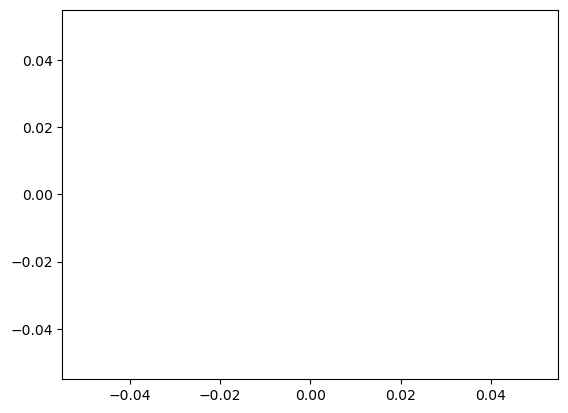

In [22]:
plt.plot(l_vals, mem_max_by_l, linestyle="--", linewidth=2.5, color="black",
         label=r"$\mathbb{E}[\max(\Delta_C,\Delta_D)]$")
plt.fill_between(
    l_vals,
    mem_max_by_l - mem_max_std,
    mem_max_by_l + mem_max_std,
    alpha=0.15, color="black"
)

ax.set_xlabel("λ")
ax.set_ylabel("2nd-order effect size")
ax.set_title("Second-order memory components")
ax.grid(alpha=0.3)
ax.legend(loc="best", frameon=True)

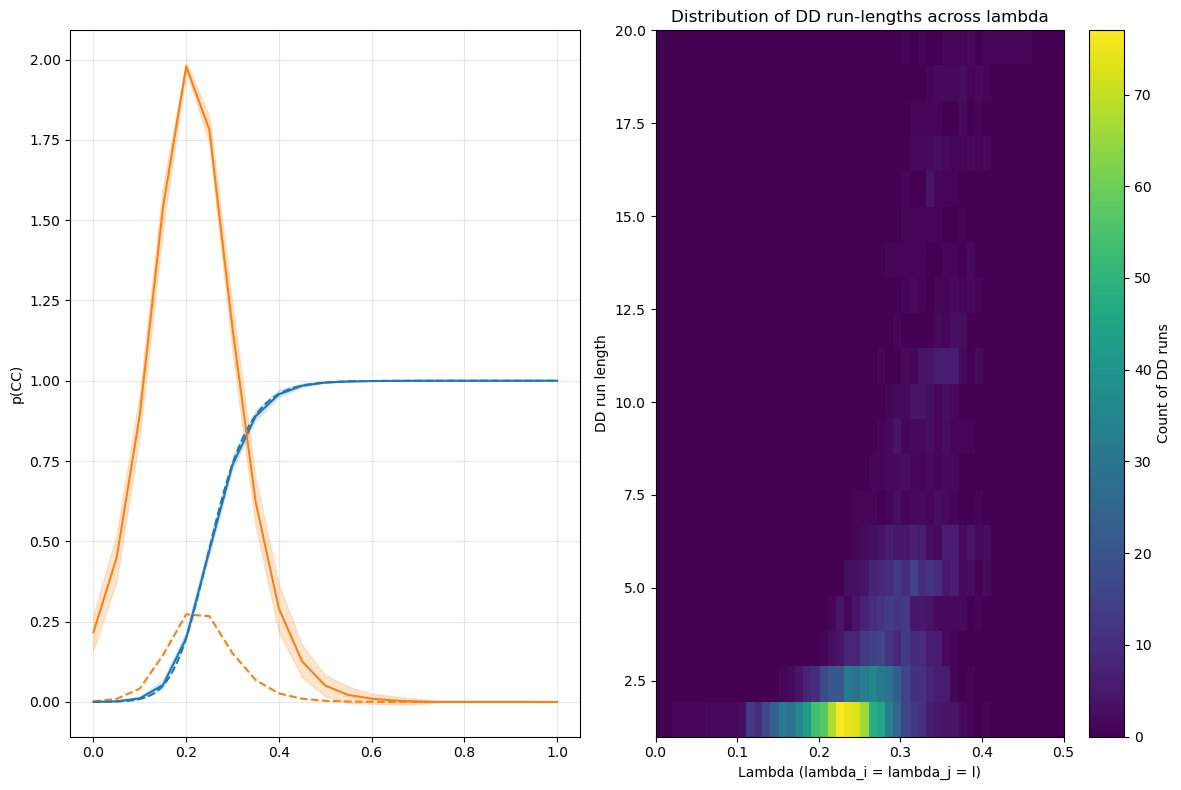

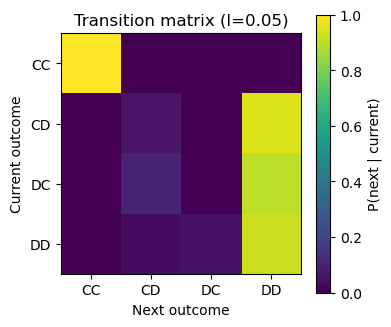

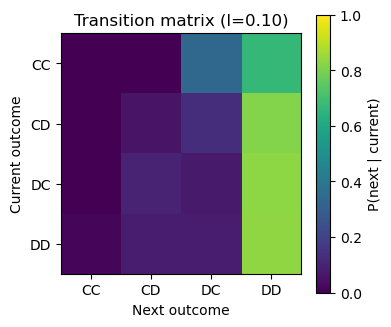

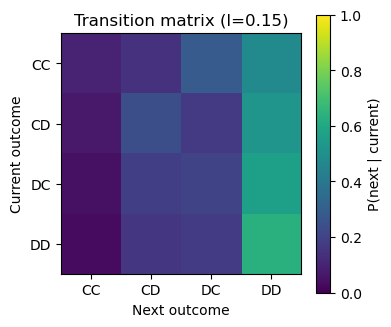

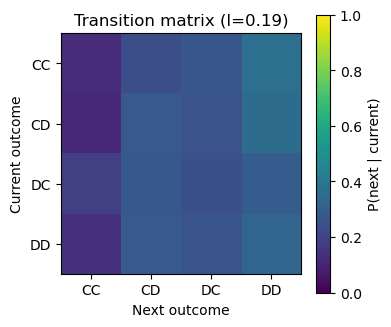

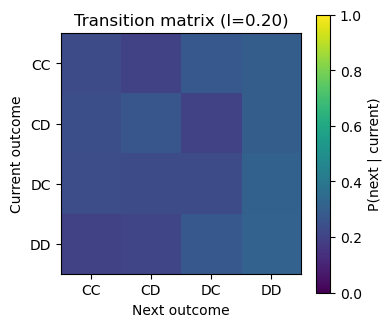

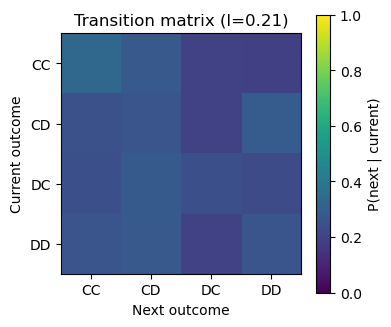

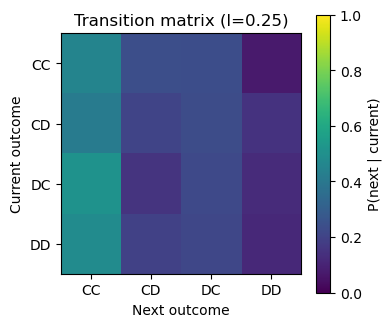

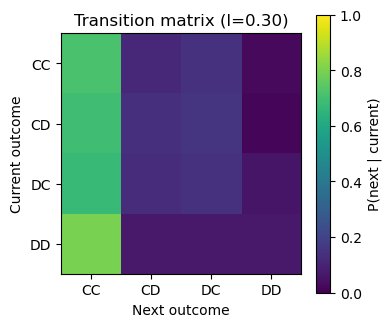

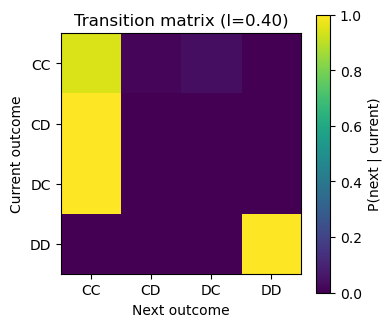

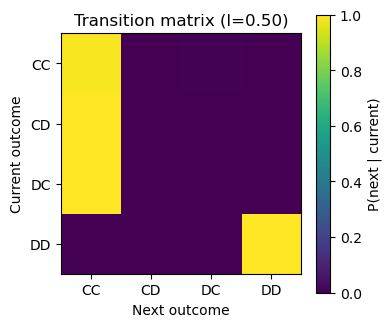

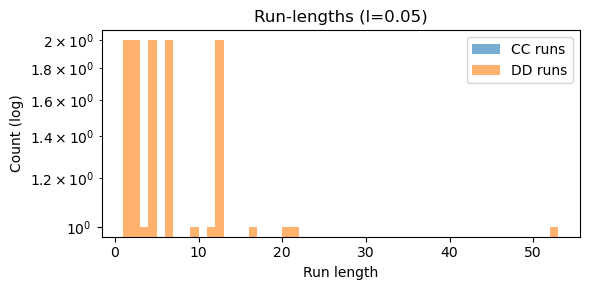

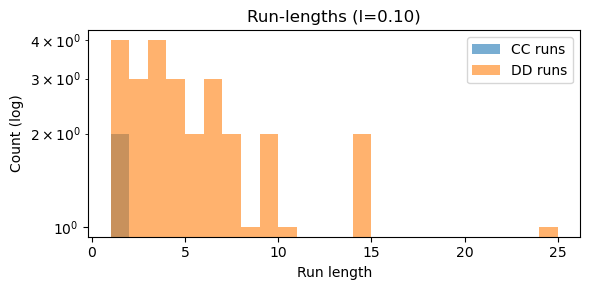

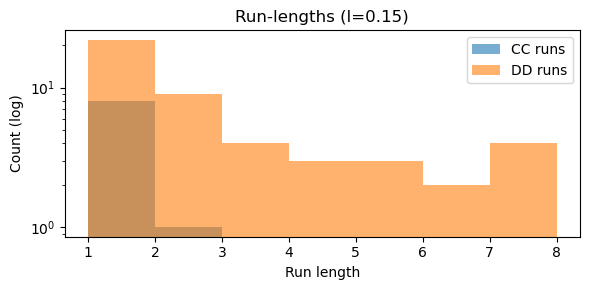

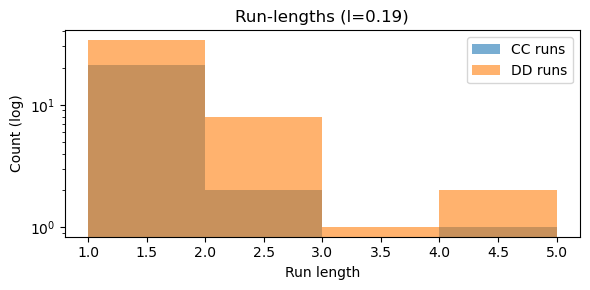

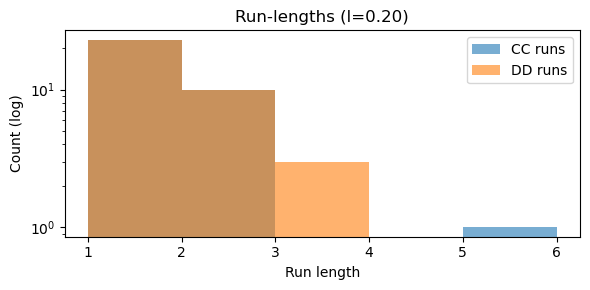

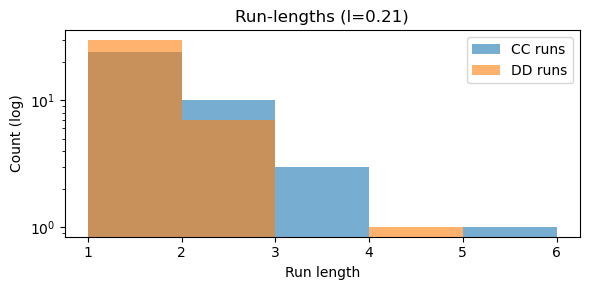

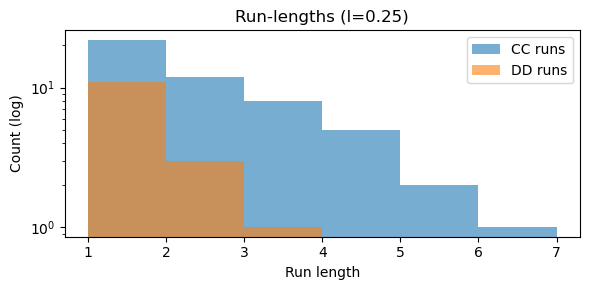

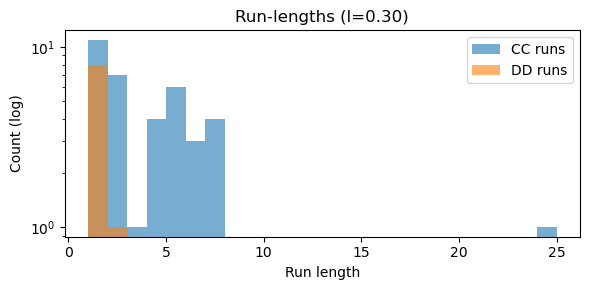

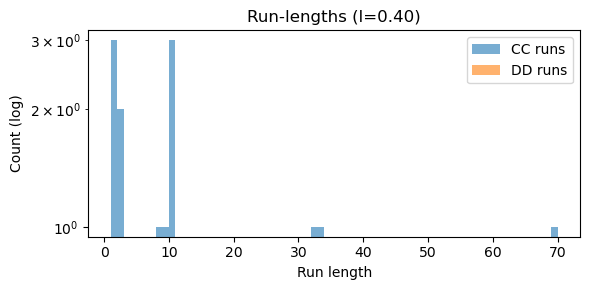

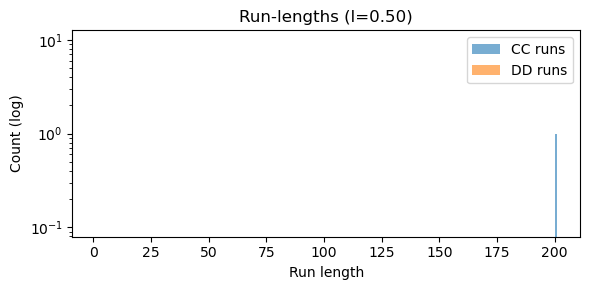

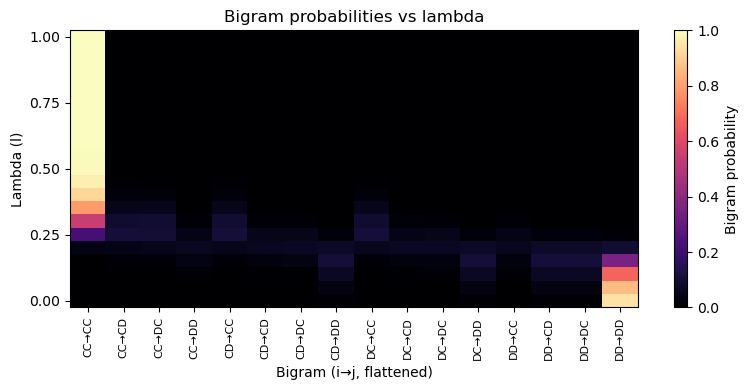

Panel F skipped for l=0.05: continuous internal state not available.
Panel F skipped for l=0.10: continuous internal state not available.
Panel F skipped for l=0.15: continuous internal state not available.
Panel F skipped for l=0.19: continuous internal state not available.
Panel F skipped for l=0.20: continuous internal state not available.
Panel F skipped for l=0.21: continuous internal state not available.
Panel F skipped for l=0.25: continuous internal state not available.
Panel F skipped for l=0.30: continuous internal state not available.
Panel F skipped for l=0.40: continuous internal state not available.
Panel F skipped for l=0.50: continuous internal state not available.


In [17]:
# Analysis and plotting functions for panels A–F

labels = ["CC", "CD", "DC", "DD"]
n_states = len(labels)

def _outcome_entropy(outcomes):
    counts = np.bincount(outcomes, minlength=n_states).astype(float)
    probs = counts / np.maximum(counts.sum(), 1.0)
    mask = probs > 0
    return -np.sum(probs[mask] * np.log2(probs[mask]))

def _switching_rate(outcomes):
    outcomes = np.asarray(outcomes)
    if len(outcomes) < 2:
        return 0.0
    return np.mean(outcomes[1:] != outcomes[:-1])

def _transition_matrix(outcomes):
    outcomes = np.asarray(outcomes, dtype=int)
    mat = np.zeros((n_states, n_states), dtype=float)
    if len(outcomes) < 2:
        return mat
    i = outcomes[:-1]
    j = outcomes[1:]
    for a, b in zip(i, j):
        mat[a, b] += 1
    row_sums = mat.sum(axis=1, keepdims=True)
    return np.divide(mat, row_sums, where=row_sums > 0)

def _run_lengths(outcomes, target):
    outcomes = np.asarray(outcomes, dtype=int)
    lengths = []
    run = 0
    for v in outcomes:
        if v == target:
            run += 1
        else:
            if run > 0:
                lengths.append(run)
            run = 0
    if run > 0:
        lengths.append(run)
    return np.asarray(lengths, dtype=int)

def _bigram_probs(outcomes):
    outcomes = np.asarray(outcomes, dtype=int)
    mat = np.zeros((n_states, n_states), dtype=float)
    if len(outcomes) < 2:
        return mat
    i = outcomes[:-1]
    j = outcomes[1:]
    for a, b in zip(i, j):
        mat[a, b] += 1
    return mat / np.maximum(mat.sum(), 1.0)

def analyze_metrics_across_l(l_vals, seeds, T=300):
    pcc_mean, pcc_std = [], []
    ent_mean, ent_std = [], []
    sw_mean, sw_std = [], []

    for l in l_vals:
        pcc_list, ent_list, sw_list = [], [], []
        for seed in seeds:
            res = run_single_experiment(l, l, T=T, seed=seed)
            outcomes = np.asarray(res.outcomes, dtype=int)
            pcc_list.append(np.mean(outcomes == 0))
            ent_list.append(_outcome_entropy(outcomes))
            sw_list.append(_switching_rate(outcomes))
        pcc_mean.append(np.mean(pcc_list))
        pcc_std.append(np.std(pcc_list))
        ent_mean.append(np.mean(ent_list))
        ent_std.append(np.std(ent_list))
        sw_mean.append(np.mean(sw_list))
        sw_std.append(np.std(sw_list))

    return {
        "pcc_mean": np.asarray(pcc_mean),
        "pcc_std": np.asarray(pcc_std),
        "ent_mean": np.asarray(ent_mean),
        "ent_std": np.asarray(ent_std),
        "sw_mean": np.asarray(sw_mean),
        "sw_std": np.asarray(sw_std),
    }

def plot_panel_a(l_vals, metrics):
    plt.figure(figsize=(12, 8))

    plt.subplot(1, 2, 1)
    plt.plot(l_vals, metrics["pcc_mean"], label="p(CC)")
    plt.plot(l_vals[0:-1], np.diff(metrics["pcc_mean"]), label="d(p(CC))/dl", linestyle="--")
    plt.fill_between(
        l_vals,
        metrics["pcc_mean"] - metrics["pcc_std"],
        metrics["pcc_mean"] + metrics["pcc_std"],
        alpha=0.2,
    )


    beta = 4.0
    beta_o = beta_s = beta

    # PD payoffs (agent i vs agent j)
    # (C,C): (3,3); (C,D): (0,5); (D,C): (5,0); (D,D): (1,1)

    # Opponent response probabilities q_j(a_j | a_i) ∝ exp(beta_o * u_j(a_i,a_j))
    # If i plays C: opponent payoffs are 3 (if C) vs 5 (if D)
    qCC = np.exp(beta_o * 3) / (np.exp(beta_o * 3) + np.exp(beta_o * 5))  # q_j(C | C)
    qDC = 1 - qCC                                                       # q_j(D | C)

    # If i plays D: opponent payoffs are 0 (if C) vs 1 (if D)
    qCD = np.exp(beta_o * 0) / (np.exp(beta_o * 0) + np.exp(beta_o * 1))  # q_j(C | D)
    qDD = 1 - qCD                                                       # q_j(D | D)

    lmbda = np.linspace(0, 1, 1001)

    # Expected social utility U(a_i) = E[(1-λ)u_i + λ u_j]
    U_C = 3 * qCC + (5 * lmbda) * qDC
    U_D = (5 * (1 - lmbda)) * qCD + 1 * qDD

    # Choice probability p(λ) = softmax over U with precision beta_s
    # For two actions: p = sigmoid(beta_s*(U_C - U_D))
    z = beta_s * (U_C - U_D)
    p = 1 / (1 + np.exp(-z))

    P_CC = p**2

    # Analytic derivative
    dU_C = 5 * qDC * np.ones_like(lmbda)
    dU_D = -5 * qCD * np.ones_like(lmbda)
    dz = beta_s * (dU_C - dU_D)  # = 5*beta_s*(qDC+qCD)
    dp = p * (1 - p) * dz
    dP_CC = 2 * p * dp

    # Plot P(CC)
    plt.plot(lmbda, P_CC, '--', label="Analytic P(CC)", color="tab:blue")
  
   
    plt.plot(l_vals, metrics["ent_mean"], label="Entropy", color="tab:orange")
    plt.fill_between(
        l_vals,
        metrics["ent_mean"] - metrics["ent_std"],
        metrics["ent_mean"] + metrics["ent_std"],
        alpha=0.2,
        color="tab:orange",
    )
    plt.ylabel("p(CC)")
    plt.grid(alpha=0.3)
    N_bins = 20
    l_vals_selected = np.linspace(0, 0.5, 50)
    run_heat_map = np.zeros((N_bins, len(l_vals_selected)))
    
    for i, l in enumerate(l_vals_selected):
        res = run_single_experiment(l, l, T=T, seed=10)
        outcomes = np.asarray(res.outcomes, dtype=int)
        dd_runs = _run_lengths(outcomes, 3)
        cc_runs = _run_lengths(outcomes, 0)

        run_heat_map[:, i] = np.histogram(cc_runs, bins=N_bins, range=(1, N_bins+1))[0]

    plt.subplot(1, 2, 2)
    plt.imshow(run_heat_map, aspect="auto", origin="lower", extent=(l_vals_selected[0], l_vals_selected[-1], 1, N_bins))
    plt.colorbar(label="Count of DD runs")
    plt.xlabel("Lambda (lambda_i = lambda_j = l)")
    plt.ylabel("DD run length")
    plt.title("Distribution of DD run-lengths across lambda")
    plt.tight_layout()
    plt.show()

def plot_panel_b(l_vals_selected, T=500, seed=0):
    for l in l_vals_selected:
        res = run_single_experiment(l, l, T=T, seed=seed)
        mat = _transition_matrix(res.outcomes)

        plt.figure(figsize=(4, 3.5))
        plt.imshow(mat, vmin=0, vmax=1, cmap="viridis")
        plt.colorbar(label="P(next | current)")
        plt.xticks(range(n_states), labels)
        plt.yticks(range(n_states), labels)
        plt.xlabel("Next outcome")
        plt.ylabel("Current outcome")
        plt.title(f"Transition matrix (l={l:.2f})")
        plt.tight_layout()
        plt.show()

def plot_panel_c_recurrence(l_vals_selected, T=200, seed=0):
    for l in l_vals_selected:
        res = run_single_experiment(l, l, T=T, seed=seed, defect_interval=(0, -50))  
        outcomes = np.asarray(res.outcomes, dtype=int)

        rec = (outcomes[:, None] == outcomes[None, :]).astype(np.uint8)

        plt.figure(figsize=(4, 4))
        plt.imshow(rec, cmap="gray_r", origin="lower", vmin=0, vmax=1)
        plt.title(f"Recurrence plot (l={l:.2f})")
        plt.xlabel("Time")
        plt.ylabel("Time")
        step = max(1, T // 6)
        ticks = np.arange(0, T, step)
        plt.xticks(ticks)
        plt.yticks(ticks)
        plt.tight_layout()
        plt.show()

def plot_lagged_recurrence(l_vals_selected, T=200, seed=0):
    plt.figure(figsize=(6, 4))

    for l in l_vals_selected:
        res = run_single_experiment(l, l, T=T, seed=seed)
        outcomes = np.asarray(res.outcomes, dtype=int)

        max_lag = T // 2
        lags = np.arange(max_lag)
        lag_rec = np.zeros(max_lag)

        for tau in lags:
            if tau == 0:
                lag_rec[tau] = 1.0
            else:
                lag_rec[tau] = np.mean(outcomes[:-tau] == outcomes[tau:])

        plt.plot(lags, lag_rec, label=f"l={l:.2f}")

    plt.xlabel("Lag τ")
    plt.ylabel("Recurrence probability")
    plt.title("Lagged recurrence (symbolic)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_panel_d_runlengths(l_vals_selected, T=600, seed=0):
    for l in l_vals_selected:
        res = run_single_experiment(l, l, T=T, seed=seed)
        outcomes = np.asarray(res.outcomes, dtype=int)

        cc_runs = _run_lengths(outcomes, 0)
        dd_runs = _run_lengths(outcomes, 3)

        plt.figure(figsize=(6, 3))
        bins = np.arange(1, max(cc_runs.max(initial=1), dd_runs.max(initial=1)) + 2)
        plt.hist(cc_runs, bins=bins, alpha=0.6, label="CC runs")
        plt.hist(dd_runs, bins=bins, alpha=0.6, label="DD runs")
        plt.yscale("log")
        plt.xlabel("Run length")
        plt.ylabel("Count (log)")
        plt.title(f"Run-lengths (l={l:.2f})")
        plt.legend()
        plt.tight_layout()
        plt.show()

def plot_panel_e_bigrams(l_vals, seeds, T=300):
    bigram_means = np.zeros((len(l_vals), n_states, n_states))
    for idx, l in enumerate(l_vals):
        mats = []
        for seed in seeds:
            res = run_single_experiment(l, l, T=T, seed=seed)
            mats.append(_bigram_probs(res.outcomes))
        bigram_means[idx] = np.mean(mats, axis=0)

    plt.figure(figsize=(8, 4))
    plt.imshow(
        bigram_means.reshape(len(l_vals), -1),
        aspect="auto",
        origin="lower",
        cmap="magma",
    )
    plt.colorbar(label="Bigram probability")
    plt.xlabel("Bigram (i→j, flattened)")
    plt.ylabel("Lambda (l)")
    plt.title("Bigram probabilities vs lambda")
    plt.xticks(
        np.arange(n_states * n_states),
        [f"{labels[i]}→{labels[j]}" for i in range(n_states) for j in range(n_states)],
        rotation=90,
        fontsize=8,
    )
    plt.yticks(np.linspace(0, len(l_vals) - 1, 5), [f"{l_vals[int(k)]:.2f}" for k in np.linspace(0, len(l_vals) - 1, 5)])
    plt.tight_layout()
    plt.show()

def plot_panel_f_lyapunov_proxy(l, T=300, seed=0):
    # Placeholder for continuous-state divergence; if no internal state available, skip.
    # This function assumes run_single_experiment exposes continuous internal states
    # as res.state_i, res.state_j (not present here), so we only show a guard message.
    print(f"Panel F skipped for l={l:.2f}: continuous internal state not available.")

# ---- Run the analyses ----
l_vals = np.linspace(0.0, 1.0, 21)
seeds = np.arange(50)
T_short = 300

metrics = analyze_metrics_across_l(l_vals, seeds, T=T_short)
plot_panel_a(l_vals, metrics)

# Select l values: low, mid (peak variability proxy), high
peak_idx = int(np.argmax(metrics["ent_mean"]))
l_selected = [0.05, 0.1, 0.15, 0.19, 0.2, 0.21, 0.25, 0.3, 0.4, 0.5]

plot_panel_b(l_selected, T=500, seed=0)
# plot_panel_c_recurrence(l_selected, T=100, seed=0)
# plot_lagged_recurrence(l_selected, T=200, seed=0)
plot_panel_d_runlengths(l_selected, T=200, seed=0)

plot_panel_e_bigrams(l_vals, seeds, T=T_short)

for l in l_selected:
    plot_panel_f_lyapunov_proxy(l, T=400, seed=0)

/tmp/ipykernel_74892/850129818.py:237: RuntimeWarning: Mean of empty slice
  metrics_by_l[k].append(np.nanmean(v))
/home/aljiro/miniconda-empathy/envs/empathy-prisoner-dilemma/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


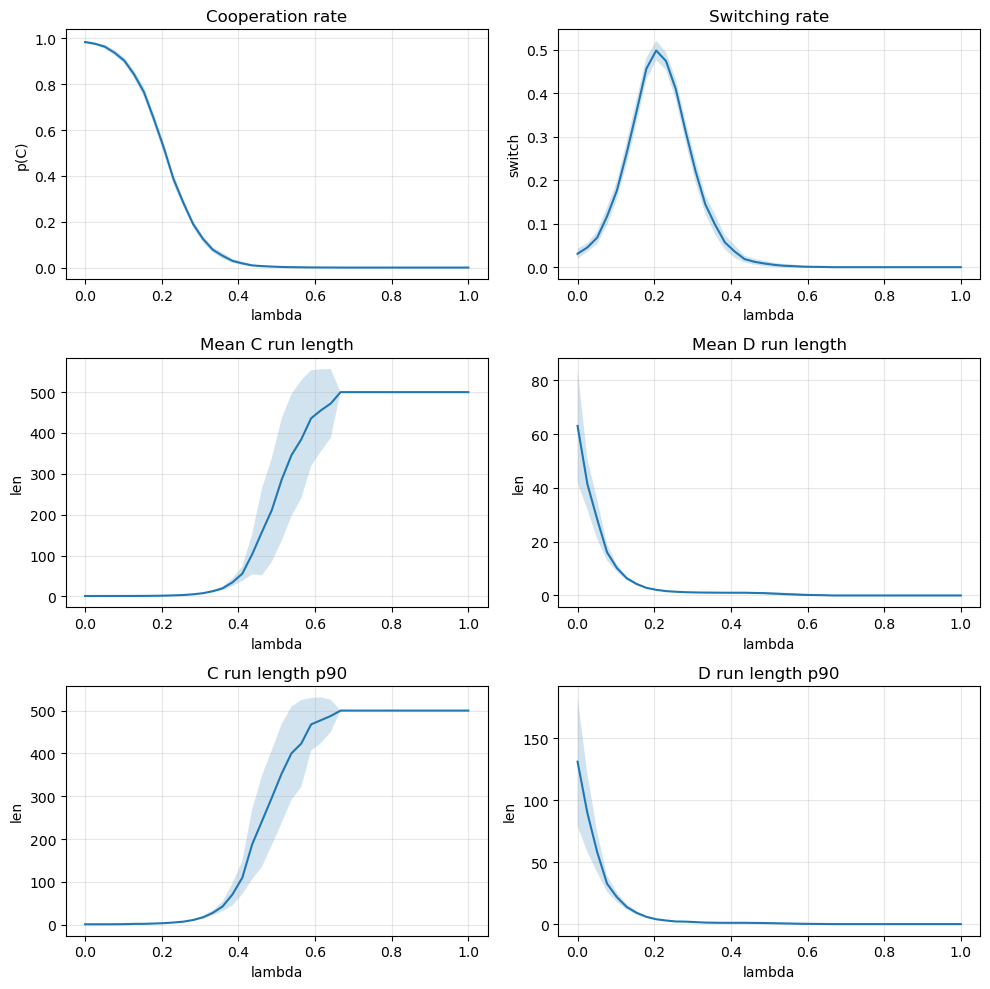

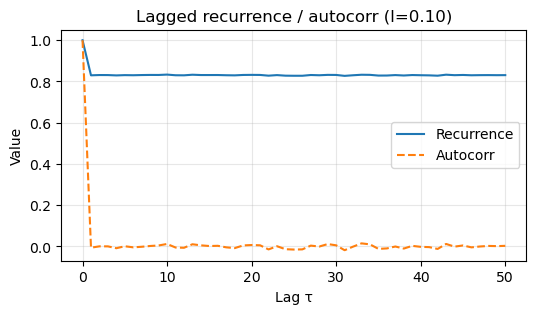

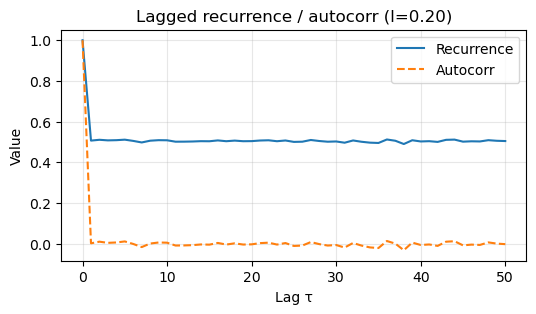

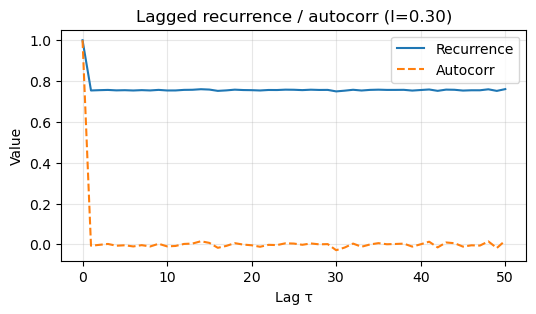

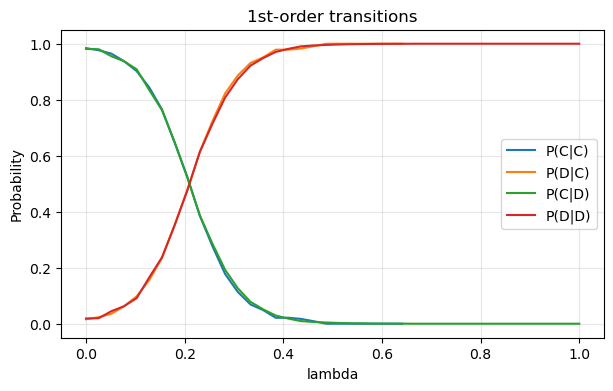

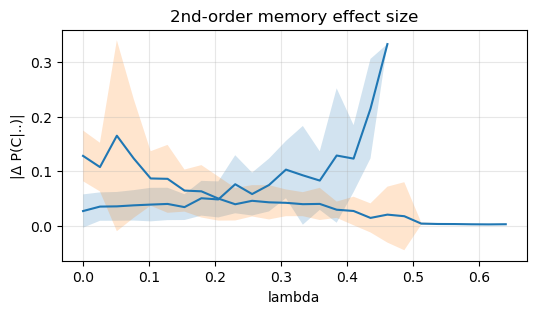

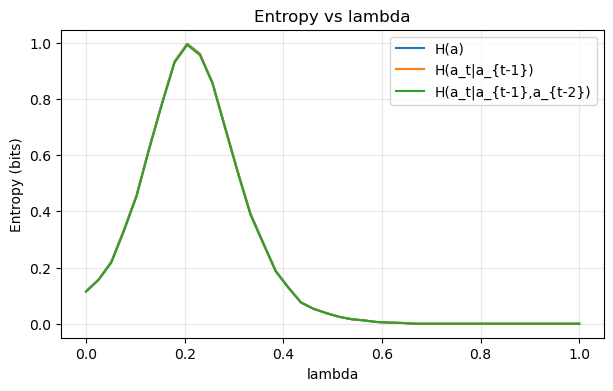

In [18]:
# Analysis for actions_i across lambda values (uses existing run_single_experiment, np, plt, lambda_vals, seeds)
lambda_vals = np.linspace(0.0, 1.0, 40)
seeds = np.arange(30)

def _run_lengths_binary(a, val):
    lengths = []
    run = 0
    for v in a:
        if v == val:
            run += 1
        else:
            if run > 0:
                lengths.append(run)
            run = 0
    if run > 0:
        lengths.append(run)
    return np.asarray(lengths, dtype=int)

def _switch_rate(a):
    if len(a) < 2:
        return 0.0
    return np.mean(a[1:] != a[:-1])

def _entropy_binary(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

def _conditional_entropy(a, order=1):
    a = np.asarray(a, dtype=int)
    if len(a) <= order:
        return 0.0
    if order == 1:
        prev = a[:-1]
        curr = a[1:]
        h = 0.0
        for s in [0, 1]:
            mask = prev == s
            if np.any(mask):
                p = np.mean(curr[mask])
                h += np.mean(mask) * _entropy_binary(p)
        return h
    if order == 2:
        prev2 = a[:-2]
        prev1 = a[1:-1]
        curr = a[2:]
        h = 0.0
        for s2 in [0, 1]:
            for s1 in [0, 1]:
                mask = (prev2 == s2) & (prev1 == s1)
                if np.any(mask):
                    p = np.mean(curr[mask])
                    h += np.mean(mask) * _entropy_binary(p)
        return h
    raise ValueError("order must be 1 or 2")

def _transition_probs(a):
    a = np.asarray(a, dtype=int)
    if len(a) < 2:
        return 0.0, 0.0, 0.0, 0.0
    prev = a[:-1]
    curr = a[1:]
    p_c_given_c = np.mean(curr[prev == 1]) if np.any(prev == 1) else np.nan
    p_d_given_c = 1 - p_c_given_c if not np.isnan(p_c_given_c) else np.nan
    p_c_given_d = np.mean(curr[prev == 0]) if np.any(prev == 0) else np.nan
    p_d_given_d = 1 - p_c_given_d if not np.isnan(p_c_given_d) else np.nan
    return p_c_given_c, p_d_given_c, p_c_given_d, p_d_given_d

def _second_order_effect(a):
    a = np.asarray(a, dtype=int)
    if len(a) < 3:
        return np.nan
    x2 = a[:-2]
    x1 = a[1:-1]
    x0 = a[2:]
    def _p_c(mask):
        return np.mean(x0[mask]) if np.any(mask) else np.nan
    p_c_cc = _p_c((x2 == 1) & (x1 == 1))
    p_c_dc = _p_c((x2 == 0) & (x1 == 1))
    p_c_cd = _p_c((x2 == 1) & (x1 == 0))
    p_c_dd = _p_c((x2 == 0) & (x1 == 0))
    diffs = [np.abs(p_c_cc - p_c_dc), np.abs(p_c_cd - p_c_dd)]
    return np.abs(p_c_cc - p_c_dc), np.abs(p_c_cd - p_c_dd)#np.nanmax(diffs)

def _lagged_recurrence(a, max_lag):
    a = np.asarray(a, dtype=int)
    lags = np.arange(max_lag + 1)
    r = np.zeros_like(lags, dtype=float)
    for i, tau in enumerate(lags):
        if tau == 0:
            r[i] = 1.0
        else:
            r[i] = np.mean(a[:-tau] == a[tau:])
    return lags, r

def _lagged_autocorr(a, max_lag):
    a = np.asarray(a, dtype=float)
    a = a - a.mean()
    var = np.mean(a * a)
    lags = np.arange(max_lag + 1)
    ac = np.zeros_like(lags, dtype=float)
    for i, tau in enumerate(lags):
        if tau == 0:
            ac[i] = 1.0
        else:
            ac[i] = np.mean(a[:-tau] * a[tau:]) / (var + 1e-12)
    return lags, ac

def _recurrence_metrics(a, L=3, V=3):
    a = np.asarray(a, dtype=int)
    n = len(a)
    if n == 0:
        return 0.0, 0.0, 0.0
    R = (a[:, None] == a[None, :]).astype(np.uint8)
    rr = R.mean()

    # Diagonal lengths (excluding main diagonal)
    det_points = 0
    rec_points = R.sum()
    for k in range(-n + 1, n):
        if k == 0:
            continue
        diag = np.diagonal(R, offset=k)
        run = 0
        for v in diag:
            if v:
                run += 1
            else:
                if run >= L:
                    det_points += run
                run = 0
        if run >= L:
            det_points += run
    det = det_points / rec_points if rec_points > 0 else 0.0

    # Vertical line lengths
    lam_points = 0
    for j in range(n):
        col = R[:, j]
        run = 0
        for v in col:
            if v:
                run += 1
            else:
                if run >= V:
                    lam_points += run
                run = 0
        if run >= V:
            lam_points += run
    lam = lam_points / rec_points if rec_points > 0 else 0.0
    return rr, det, lam

def _spectrum_slope(a, fmin=0.05, fmax=0.4):
    a = np.asarray(a, dtype=float) - np.mean(a)
    n = len(a)
    freqs = np.fft.rfftfreq(n, d=1.0)
    power = np.abs(np.fft.rfft(a)) ** 2
    mask = (freqs > 0) & (freqs >= fmin) & (freqs <= fmax)
    if np.sum(mask) < 2:
        return freqs, power, np.nan
    x = np.log(freqs[mask])
    y = np.log(power[mask] + 1e-12)
    slope, _ = np.polyfit(x, y, 1)
    return freqs, power, slope

def _hamming_over_time(a, b):
    a = np.asarray(a, dtype=int)
    b = np.asarray(b, dtype=int)
    n = min(len(a), len(b))
    return np.mean(a[:n] != b[:n]), (a[:n] != b[:n]).astype(float)

# --- Parameters ---
l_vals = lambda_vals
T = 500
max_lag = 50
selected_l = [0.1, 0.2, 0.3]

# --- 1) Metrics vs l ---
metrics_by_l = {
    "pC": [], "sw": [],
    "runC_mean": [], "runD_mean": [],
    "runC_p90": [], "runD_p90": [],
    "H": [], "H1": [], "H2": [],
    "mem2_C": [], "mem2_D": [],
    "pC_C": [], "pD_C": [], "pC_D": [], "pD_D": [],
    "RR": [], "DET": [], "LAM": [],
}

metrics_std = {k: [] for k in metrics_by_l.keys()}

for l in l_vals:
    pC_list, sw_list = [], []
    runC_mean, runD_mean = [], []
    runC_p90, runD_p90 = [], []
    H_list, H1_list, H2_list = [], [], []
    mem2_list_C = []
    mem2_list_D = []
    pC_C, pD_C, pC_D, pD_D = [], [], [], []
    RR_list, DET_list, LAM_list = [], [], []

    for seed in seeds:
        res = run_single_experiment(l, l, T=T, seed=int(seed))
        a = np.asarray(res.actions_i, dtype=int)

        pC_list.append(np.mean(a))
        sw_list.append(_switch_rate(a))

        rc = _run_lengths_binary(a, 0)
        rd = _run_lengths_binary(a, 1)
        runC_mean.append(rc.mean() if rc.size else 0.0)
        runD_mean.append(rd.mean() if rd.size else 0.0)
        runC_p90.append(np.percentile(rc, 90) if rc.size else 0.0)
        runD_p90.append(np.percentile(rd, 90) if rd.size else 0.0)

        H_list.append(_entropy_binary(np.mean(a)))
        H1_list.append(_conditional_entropy(a, order=1))
        H2_list.append(_conditional_entropy(a, order=2))
        mem_C, mem_D = _second_order_effect(a)

        mem2_list_C.append(mem_C)
        mem2_list_D.append(mem_D)

        pc_c, pd_c, pc_d, pd_d = _transition_probs(a)
        pC_C.append(pc_c); pD_C.append(pd_c); pC_D.append(pc_d); pD_D.append(pd_d)

        rr, det, lam = _recurrence_metrics(a, L=3, V=3)
        RR_list.append(rr); DET_list.append(det); LAM_list.append(lam)

    for k, v in [
        ("pC", pC_list), ("sw", sw_list),
        ("runC_mean", runC_mean), ("runD_mean", runD_mean),
        ("runC_p90", runC_p90), ("runD_p90", runD_p90),
        ("H", H_list), ("H1", H1_list), ("H2", H2_list),
        ("mem2_C", mem2_list_C), ("mem2_D", mem2_list_D),
        ("pC_C", pC_C), ("pD_C", pD_C), ("pC_D", pC_D), ("pD_D", pD_D),
        ("RR", RR_list), ("DET", DET_list), ("LAM", LAM_list),
    ]:
        metrics_by_l[k].append(np.nanmean(v))
        metrics_std[k].append(np.nanstd(v))

# Plot phase-transition summaries
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.ravel()
def _plot_mean_std(ax, y, ystd, title, ylabel):
    ax.plot(l_vals, y, color="tab:blue")
    ax.fill_between(l_vals, np.array(y) - np.array(ystd), np.array(y) + np.array(ystd), alpha=0.2)
    ax.set_title(title); ax.set_xlabel("lambda"); ax.set_ylabel(ylabel); ax.grid(alpha=0.3)

_plot_mean_std(axes[0], metrics_by_l["pC"], metrics_std["pC"], "Cooperation rate", "p(C)")
_plot_mean_std(axes[1], metrics_by_l["sw"], metrics_std["sw"], "Switching rate", "switch")
_plot_mean_std(axes[2], metrics_by_l["runC_mean"], metrics_std["runC_mean"], "Mean C run length", "len")
_plot_mean_std(axes[3], metrics_by_l["runD_mean"], metrics_std["runD_mean"], "Mean D run length", "len")
_plot_mean_std(axes[4], metrics_by_l["runC_p90"], metrics_std["runC_p90"], "C run length p90", "len")
_plot_mean_std(axes[5], metrics_by_l["runD_p90"], metrics_std["runD_p90"], "D run length p90", "len")
plt.tight_layout(); plt.show()

# --- 2) Lagged recurrence & autocorrelation (selected l) ---
for l in selected_l:
    r_accum, ac_accum = [], []
    for seed in seeds:
        res = run_single_experiment(l, l, T=T, seed=int(seed))
        a = np.asarray(res.actions_i, dtype=int)
        lags, r = _lagged_recurrence(a, max_lag=max_lag)
        _, ac = _lagged_autocorr(a, max_lag=max_lag)
        r_accum.append(r)
        ac_accum.append(ac)
    r_mean = np.mean(r_accum, axis=0)
    ac_mean = np.mean(ac_accum, axis=0)

    plt.figure(figsize=(6, 3))
    plt.plot(lags, r_mean, label="Recurrence")
    plt.plot(lags, ac_mean, label="Autocorr", linestyle="--")
    plt.title(f"Lagged recurrence / autocorr (l={l:.2f})")
    plt.xlabel("Lag τ"); plt.ylabel("Value"); plt.grid(alpha=0.3); plt.legend(); plt.show()

# --- 3) Transition probs and memory effect vs l ---
plt.figure(figsize=(7, 4))
plt.plot(l_vals, metrics_by_l["pC_C"], label="P(C|C)")
plt.plot(l_vals, metrics_by_l["pD_C"], label="P(D|C)")
plt.plot(l_vals, metrics_by_l["pC_D"], label="P(C|D)")
plt.plot(l_vals, metrics_by_l["pD_D"], label="P(D|D)")
plt.xlabel("lambda"); plt.ylabel("Probability"); plt.title("1st-order transitions")
plt.grid(alpha=0.3); plt.legend(); plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
_plot_mean_std(ax, metrics_by_l["mem2_C"], metrics_std["mem2_C"], "2nd-order memory effect C", "|Δ P(C|.C)|")
_plot_mean_std(ax, metrics_by_l["mem2_D"], metrics_std["mem2_D"], "2nd-order memory effect D", "|Δ P(C|.D)|")
plt.xlabel("lambda"); plt.ylabel("|Δ P(C|..)|")
plt.title("2nd-order memory effect size"); plt.grid(alpha=0.3); plt.show()

# --- 4) Entropy estimates ---
plt.figure(figsize=(7, 4))
plt.plot(l_vals, metrics_by_l["H"], label="H(a)")
plt.plot(l_vals, metrics_by_l["H1"], label="H(a_t|a_{t-1})")
plt.plot(l_vals, metrics_by_l["H2"], label="H(a_t|a_{t-1},a_{t-2})")
plt.xlabel("lambda"); plt.ylabel("Entropy (bits)")
plt.title("Entropy vs lambda"); plt.grid(alpha=0.3); plt.legend(); plt.show()

# # --- 5) Recurrence plot + RQA metrics ---
# for l in selected_l:
#     res = run_single_experiment(l, l, T=T, seed=0)
#     a = np.asarray(res.actions_i, dtype=int)
#     R = (a[:, None] == a[None, :]).astype(np.uint8)
#     plt.figure(figsize=(4, 4))
#     plt.imshow(R, cmap="gray_r", origin="lower")
#     plt.title(f"Recurrence plot (l={l:.2f})")
#     plt.xlabel("t"); plt.ylabel("t"); plt.tight_layout(); plt.show()

# plt.figure(figsize=(7, 3))
# plt.plot(l_vals, metrics_by_l["RR"], label="RR")
# plt.plot(l_vals, metrics_by_l["DET"], label="DET")
# plt.plot(l_vals, metrics_by_l["LAM"], label="LAM")
# plt.xlabel("lambda"); plt.ylabel("Metric")
# plt.title("Recurrence metrics vs lambda"); plt.grid(alpha=0.3); plt.legend(); plt.show()

# # --- 6) Power spectrum (selected l) ---
# for l in selected_l:
#     res = run_single_experiment(l, l, T=T, seed=0)
#     a = np.asarray(res.actions_i, dtype=int)
#     freqs, power, slope = _spectrum_slope(a)
#     mask = freqs > 0
#     plt.figure(figsize=(6, 3))
#     plt.plot(freqs[mask], np.log(power[mask] + 1e-12))
#     plt.title(f"Log power spectrum (l={l:.2f}), slope≈{slope:.2f}")
#     plt.xlabel("Frequency"); plt.ylabel("log Power")
#     plt.grid(alpha=0.3); plt.show()

# # --- 7) Sensitivity via forced flip (actions-only proxy) ---
# for l in selected_l:
#     hamming_curves = []
#     for seed in seeds[:10]:
#         res_a = run_single_experiment(l, l, T=T, seed=int(seed))
#         a = np.asarray(res_a.actions_i, dtype=int)

#         # Force flip at t=0 by toggling action and then re-simulate? If no control, create proxy.
#         # Proxy: flip first action and compare divergence under same realized sequence.
#         b = a.copy()
#         b[0] = 1 - b[0]
#         _, ham_curve = _hamming_over_time(a, b)
#         hamming_curves.append(ham_curve)

#     ham_mean = np.mean(hamming_curves, axis=0)
#     plt.figure(figsize=(6, 3))
#     plt.plot(ham_mean)
#     plt.xlabel("Time"); plt.ylabel("Hamming distance")
#     plt.title(f"Sensitivity proxy (l={l:.2f})")
#     plt.grid(alpha=0.3); plt.show()

Lambda: 0.30, Outcomes: BBBBBBBBBBBBBBBBBBBBBDBBBDBBBBBBBBBBBBBBBBBBBBBBBBBBBBDBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBDBBBBBBBBBBBBBBBBBBBDBBBDBBBBBBBBBBBDBBBBBBBBBBBBBBBBBBBBBBDBBBBBDBDBAAAAAAAAACAAAAAAAAAAACDBAAAAAAAAAAACBAAABAAAAACAAAAAAAAAAAAAAAABBAAABACCAAAAACAAAAAAAAAAAAAAAAACAAAACAAAAAACACAAAAACAAAAABACAAAACBAAAAAACAAAAAAAAAAAAACAAAAACAAAAACAABAACAAACAAAAABACBAACAACAAAAAABAAAACAAAAAABAABAAAAAAAABDAAAAAAAAAAAAAABAAAAAAAAAABAAAAAAACACAAACAAAAAAAAACAAAAAAAAAABBCAAAAAAAAABAAAAAAAADACAAACABAAAAAABAAAAABAABAAAAAACAAAAACAAAAACCAACBAAAAAACAABAAADCAAAAAAAAAAAAAAAAAAAACBBAAAABAAAAABAAAAAAAAAAAAAAAACAAAAAAAAACAAAABAAACAACAAAACABAAAACBCAAAAAAAAAAACAAAABAAAAAAAAAAAAAAAAAAAAAAAAABAAAAAAAAAAAAAAACAAAAAAAAAAAACBAADAAACACACAAAABAABAAACAAAAACBAAAABAAAAAAACAAAABAACAAAAACAAAACABAAAAAAAAAAA
Perturbed: Lambda: 0.35, Outcomes: BBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBDBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBBB

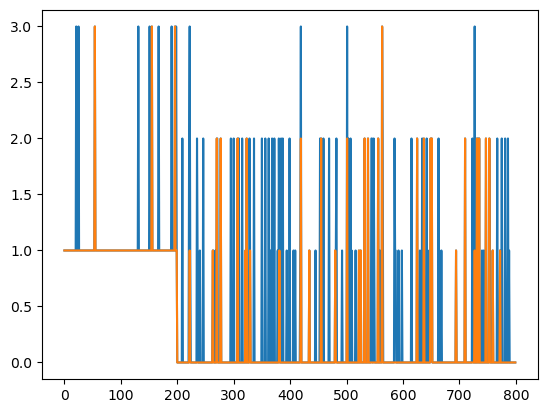

In [76]:

fig, ax = plt.subplots()
T = 800
li = 0.30
res = run_single_experiment( li, li, T=T, seed=10, beta_i=5, beta_j=5, defect_interval=(0,200), use_inversion=True)
# Map res.outcomes to letters 'A', 'B', 'C', 'D' for visualization
outcome_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
outcomes_mapped = [outcome_map.get(o, 'X') for o in res.outcomes]  # 'X' for any unexpected values
print(f"Lambda: {li:.2f}, Outcomes: {''.join(outcomes_mapped)}")
ax.plot(res.outcomes)

li += 0.05
res = run_single_experiment( li, li, T=T, seed=10, beta_i=5, beta_j=5, defect_interval=(0,200), use_inversion=True)
# Map res.outcomes to letters 'A', 'B', 'C', 'D' for visualization
outcome_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
outcomes_mapped = [outcome_map.get(o, 'X') for o in res.outcomes]  # 'X' for any unexpected values
print(f"Perturbed: Lambda: {li:.2f}, Outcomes: {''.join(outcomes_mapped)}")
ax.plot(res.outcomes)


Lambda: 0.10, Outcomes: DDDDCDCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDCDDDCDDDDCDDDDDDDDDDDDDDDDDDDDDDCDDDDDDDDDDDDCCDDDDDDDDDCDDDDDDDDDDDDDDDDDDDDDDDCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDCDDDDDDDBDDDDDDDBDDDDDDDDDDDDDDDDCDDDDDDDCCDDDDDDDDDDDDDDDDBDBDDDDDDDDDDDDDDDDDDDDCDDDDDDDDDDDDDDDDDDDDDDDDDDDBCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDCDCDDBBDDDDDDBDDDBDCDDBDDCDDDDDDDDDDDDDDDCDDDDDDDDDDDDDDDDDDDDDDDCBDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDADDDDDDCDDDDDCDDDCDDDDDDDDDDDDDDDDDDDDDDDDDCDCBDDDDDDDDDADDDDDDDADDDDDDDDDDDDACBBDDDDDDDDDDDDDDDDDDDDDDDDBDDDDCCDCCDDCDDCADDDCDDDDDCDDDDDDDDDBDDDDDDDDDDDDBBDBDDDDDDDDDDDDCDDDDDDDDDDBDDDDDDDDDDDDDCDDDDDDDDDDDDDDDDDDDDDDDDDCDDDDDDDDDDDDDDBDDDDDDDDDBDDDDDDDDDDDDDDDBBDDDDDDDDBDDDDDDDDDCDDDDDDDDDDDDDDDDBDDDDDDDDDBCCDDDDDDDCDDDDDDCDDDDDDDDDDDCBDDBDDD
Lambda: 0.11, Outcomes: DDDDCDCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDCDDDDDDDCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDCDDDCDDDDCDDDDDDDDDDDDDDDDDDDDDDCDDDDDDDDDDDDCCDDDDDDDDDCDDDDDDDDDDDDDDDDD

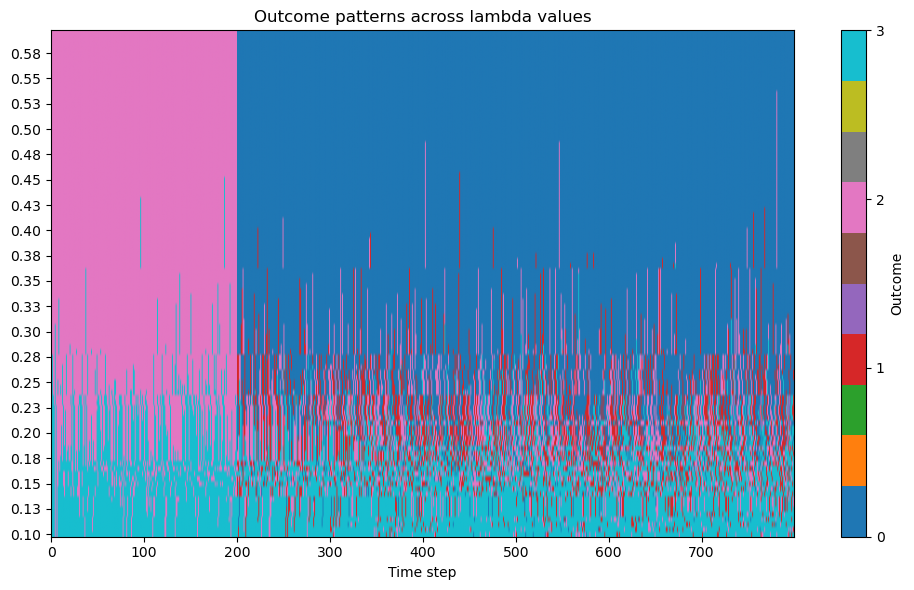

In [23]:
lambda_grid = np.linspace(0.1, 0.6, 100)
T = 800
patterns = np.zeros((len(lambda_grid), T), dtype=int)
for i, li in enumerate(lambda_grid):
    res = run_single_experiment( li, li, T=T, seed=10, beta_i=5, beta_j=5, defect_interval=(0,200), use_inversion=True)
    # Map res.outcomes to letters 'A', 'B', 'C', 'D' for visualization
    outcome_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
    outcomes_mapped = [outcome_map.get(o, 'X') for o in res.outcomes]  # 'X' for any unexpected values
    print(f"Lambda: {li:.2f}, Outcomes: {''.join(outcomes_mapped)}")
    patterns[i] = res.outcomes  # Store numeric outcomes for heatmap

plt.figure(figsize=(10, 6))
plt.imshow(patterns, aspect='auto', origin='lower', cmap='tab10')
plt.colorbar(ticks=[0, 1, 2, 3], label='Outcome')
plt.yticks(np.arange(0,len(lambda_grid), 5), [f"{l:.2f}" for l in lambda_grid[::5]])
plt.xlabel("Time step")
plt.title("Outcome patterns across lambda values")
plt.tight_layout()
plt.show()

Lambda: 0.10, Outcomes: DDDDDDBDDDDDDDDDDDDDDDDBDDDCDDDDDDBDDBDDCDDDDDDDDDDDDDDDDBDBDDDBDDDDDDBDDDDDDDDDDDDDDDDDDDDDDDDBDDDDDDCCDDCDDDDDDABDDDDDDCDDDDDDDDDDDDDBDDDDDDDDDDDCDDDDDDDDDDDDDBDDDCDDCDDDDCBDDDDDDBDDDDDDDDBBDDDDDDCDDDDDDDDDDDDDDDDDDDDDBDDDDDDDDDCDDDDDDDDDDDDDDDDDDDDDBDDDBDDDDDDDBDBDDDDDDDDDDDDDDDDDDDDDDDDDDDDCDDDDDBCDBDDCDDDDDDDDDDDDDDCDDDBDDDDCBCDCDDDDDDDCDDDDCDDDDDBDDDDBDDDDDCDDDDDDDDDCDDDDDDDBDDDDDDDDDDDDDDDCDDDDDCDBDDDDDDDDDCDDBDDDDDDDDDDDDDDDBDDDDCDDCDDCDDDDDDDDBDDDDADDADDDDDDDDDDDDDDDDDDDDDDBDDDBDDDDDDDDDDDDBDDDBDCDDDDDDDDDDDDDDDDDDDDDDDDCDDDDCCDDDDDDBCDDDDDCDDDDDDDDDDDDDDDDDDDDDDCDDCDDDDDCBDDDDDBDDDDDDDDDDDDDDBDDDDDDCBDDDDDDDBDDDDDDDDDDDDDCDDBDDDDDDDDDBDDDCDDDDDDDDDDBDDDDDDBDDDDDDDDDDDDDDDDDDDDDCDDDDDCDBDDDDBDDDDDDDDDDDDDDDDDDDDDDDDDDDDCDDDDDDDDDDCDDDDDDDDDDCDBDDCDDCDBDDCBDDDDDDDDDDDDCDDDDDDDDCDDD
Lambda: 0.11, Outcomes: DDDDDDBDDDDDDDDDDDDCDDDBDCCDDCDDDDDDDDDBDDADDDDBDDDDDDDDCDDDDDDDDDDDDDDBDDBDDDDDDCDDDDDDDDDDDCCDDDDDDBDDDDBDDDDCDDDCDDDDDDDDDDDDDDDDDDDBDBDBDDDDCBBDCDD

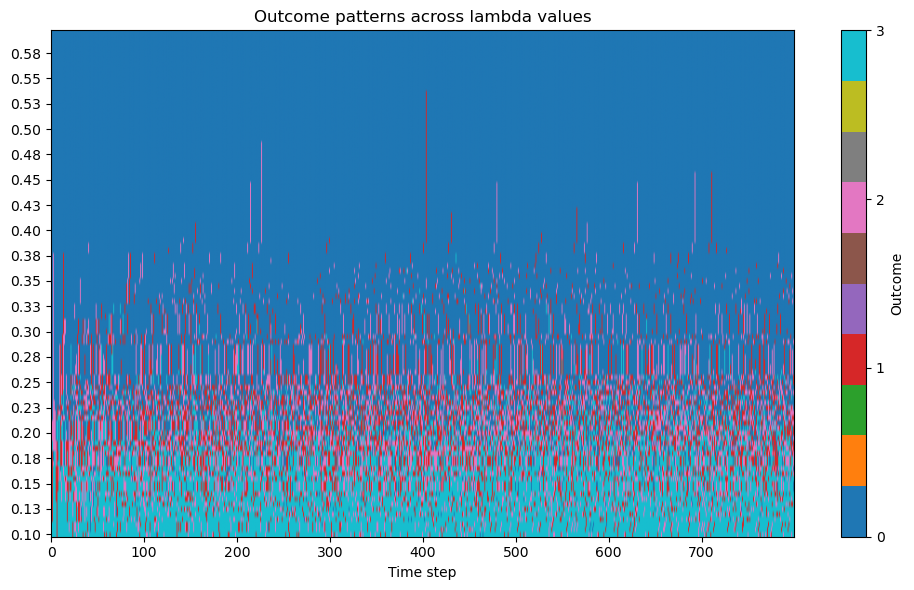

In [22]:
lambda_grid = np.linspace(0.1, 0.6, 100)
T = 800
patterns = np.zeros((len(lambda_grid), T), dtype=int)
for i, li in enumerate(lambda_grid):
    res = run_single_experiment( li, li, T=T, seed=0, beta_i=5, beta_j=5, use_inversion=True)
    # Map res.outcomes to letters 'A', 'B', 'C', 'D' for visualization
    outcome_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
    outcomes_mapped = [outcome_map.get(o, 'X') for o in res.outcomes]  # 'X' for any unexpected values
    print(f"Lambda: {li:.2f}, Outcomes: {''.join(outcomes_mapped)}")
    patterns[i] = res.outcomes  # Store numeric outcomes for heatmap

plt.figure(figsize=(10, 6))
plt.imshow(patterns, aspect='auto', origin='lower', cmap='tab10')
plt.colorbar(ticks=[0, 1, 2, 3], label='Outcome')
plt.yticks(np.arange(0,len(lambda_grid), 5), [f"{l:.2f}" for l in lambda_grid[::5]])
plt.xlabel("Time step")
plt.title("Outcome patterns across lambda values")
plt.tight_layout()
plt.show()

In [68]:

import numpy as np
import copy

from scripts.run_pd_experiments import create_pd_config
from empathy.prisoners_dilemma import ToMEmpatheticAgent, Environment

# Build config/env and base agents
np.random.seed(seed)
config = create_pd_config(T=T)
env = Environment(K=2)
lambda_i = 0.1
agent = ToMEmpatheticAgent(
    config=config,
    agent_num=0,
    empathy_factor=lambda_i,
    use_inversion=False,
    beta_self=beta_i,
    beta_other=beta_j,
)

agent_pert = copy.deepcopy(agent)

eps = 0.1
res = agent.step(t=0, observation=agent.o_init)
res_p = agent_pert.step(t=0, observation=agent_pert.o_init)

# flatten -> perturb -> write back into agent_pert.self_agent.qs
qs_list = agent_pert.self_agent.qs  # list of arrays
flat = np.concatenate([q.ravel() for q in qs_list])

flat_p = flat + eps * np.random.normal(size=flat.size)

# write back with correct shapes + renormalize each factor
k = 0
for idx, q in enumerate(qs_list):
    n = q.size
    new_q = flat_p[k:k+n].reshape(q.shape)

    # ensure it's a valid probability distribution
    new_q = np.clip(new_q, 1e-12, None)
    new_q = new_q / new_q.sum()

    qs_list[idx][...] = new_q
    k += n

deltas = []
gammas = []
actions = [0, 0]
qs_history = []
T = 50

for t in range(1, T):

    rng_state = np.random.get_state()
    obs = env.step(t=t, actions=actions)

    res = agent.step(t, observation=obs[0])
    qs_history.append(res["q_action"])
    print(res["q_action"])
    np.random.set_state(rng_state)
    res_p = agent_pert.step(t, observation=obs[0])
    
    x = np.concatenate([q.ravel() for q in res["qs"]])
    xp = np.concatenate([q.ravel() for q in res_p["qs"]])
    
    delta = np.linalg.norm(xp - x)
    gammas.append(np.log(delta / eps))

    a_i = res["exp_action"]        
    a_j = 0

    actions = [a_i, a_j]

print(gammas)

plt.plot(qs_history)

[0.06808039 0.93191961]


/tmp/ipykernel_37449/2449373508.py:67: RuntimeWarning: divide by zero encountered in log
  gammas.append(np.log(delta / eps))


KeyError: (1, 2)

In [48]:
import numpy as np
import copy

from scripts.run_pd_experiments import create_pd_config
from empathy.prisoners_dilemma import ToMEmpatheticAgent, Environment

def soften_A(A, eta: float):
    """
    Mix likelihood A with uniform noise.
    A is typically an object array/list of numpy arrays in pymdp format.
    This function returns a deep-copied, renormalized A'.
    """
    A2 = copy.deepcopy(A)

    # A2 is usually something like: A2[modality] = array(o, s)
    for m in range(len(A2)):
        Am = np.array(A2[m], dtype=float, copy=True)

        # uniform over observations given state: U[o,s] = 1/num_obs
        num_obs = Am.shape[0]
        U = np.ones_like(Am) / num_obs

        Am_new = (1.0 - eta) * Am + eta * U

        # renormalize columns so that sum_o A[o,s] = 1 for each s
        colsum = Am_new.sum(axis=0, keepdims=True)
        Am_new = Am_new / np.clip(colsum, 1e-16, None)

        A2[m] = Am_new

    return A2

def run_pair_divergence_qaction(lambda_i=0.2, beta_i=4.0, beta_j=4.0, T=100, seed=0, eta=0.1):
    np.random.seed(seed)
    config = create_pd_config(T=T)
    env = Environment(K=2)

    agent = ToMEmpatheticAgent(
        config=config, agent_num=0, empathy_factor=lambda_i,
        use_inversion=False, beta_self=beta_i, beta_other=beta_j
    )
    agent_p = copy.deepcopy(agent)

    # --- REAL STATE PERTURBATION: change agent_p's likelihood model used by inference ---
    A_pert = soften_A(agent_p.A, eta=eta)
    agent_p.A = A_pert
    agent_p.self_agent.A = A_pert   # crucial: this is what infer_states() uses 

    actions = [0, 0]

    q_traj = []
    qp_traj = []

    for t in range(T):
        obs = env.step(t=t, actions=actions)
        o = agent.o_init if t == 0 else obs[0]

        # common noise: same np.random stream for both action samples
        rng_state = np.random.get_state()
        res = agent.step(t=t, observation=o)
        np.random.set_state(rng_state)
        resp = agent_p.step(t=t, observation=o)

        q_traj.append(res["q_action"])
        qp_traj.append(resp["q_action"])

        # use base action to drive environment (or do both; choose one convention)
        actions = [int(res["exp_action"]), 0]

    q_traj = np.array(q_traj, dtype=float)
    qp_traj = np.array(qp_traj, dtype=float)

    # divergence over time
    deltas = np.linalg.norm(qp_traj - q_traj, axis=1)
    return q_traj, qp_traj, deltas

q_traj, qp_traj, deltas = run_pair_divergence_qaction()

print("Qtraj",q_traj[0])
print("QPtraj: ",qp_traj[0])
print(deltas)

Qtraj [0.44691291 0.55308709]
QPtraj:  [0.44691291 0.55308709]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


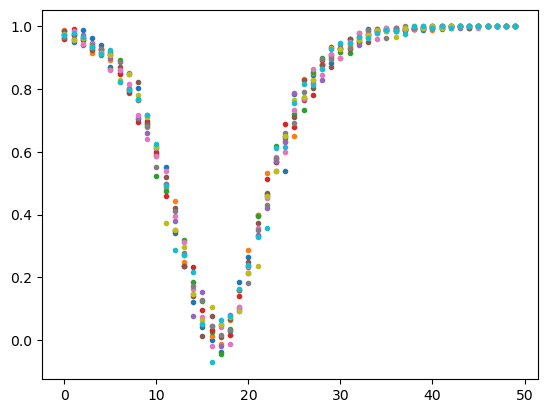

In [84]:
lambda_grid = np.linspace(0.0, 0.6, 50)
T = 500
N = 10

M = np.zeros((len(lambda_grid), N))

for i, li in enumerate(lambda_grid):
    for j in range(N):
        res = run_single_experiment( li, li, T=T, seed=np.random.randint(10000), beta_i=5, beta_j=5, use_inversion=False)
        s1 = 2*res.actions_i - 1 
        s2 = 2*res.actions_j - 1

        m = np.sum(s1*s2)/T
        M[i, j] = m
        


#scatterplot
plt.plot( M , '.')



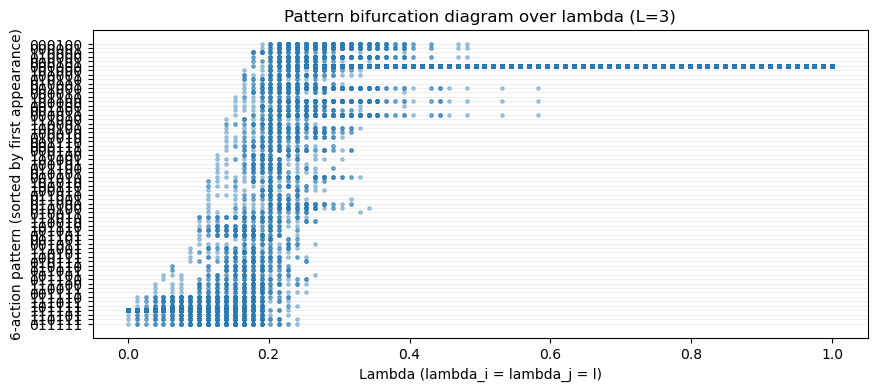

In [ ]:
# Period-doubling style diagram using action patterns of length L
l_vals = np.linspace(0.0, 1.0, 80)
T = 600
burn_in = 300
L = 3  # Length of action sequence to encode (e.g., 2 gives 4-bit patterns, 5 gives 10-bit patterns)

def _pattern_to_int_L(actions_i_seq, actions_j_seq):
    """
    Convert a sequence of actions from both agents to an integer.
    actions_i_seq: array of length L with actions from agent i
    actions_j_seq: array of length L with actions from agent j
    
    Returns: integer encoding where bits represent chronological order,
    with most recent actions at the rightmost bits.
    Pattern: (ai[0], aj[0], ai[1], aj[1], ..., ai[L-1], aj[L-1])
    """
    result = 0
    L_local = len(actions_i_seq)
    for idx in range(L_local):
        # Position from the right: 2*(L-1-idx) for aj, 2*(L-1-idx)+1 for ai
        bit_pos_i = 2 * (L_local - 1 - idx) + 1
        bit_pos_j = 2 * (L_local - 1 - idx)
        result |= (int(actions_i_seq[idx]) << bit_pos_i)
        result |= (int(actions_j_seq[idx]) << bit_pos_j)
    return result

xs, ys = [], []

for i in range(1):
    for l in l_vals:
        res = run_single_experiment(l, l, T=T, seed=np.random.randint(100000), beta_i=5, beta_j=5, use_inversion=True)
        ai = np.asarray(res.actions_i, dtype=int)
        aj = np.asarray(res.actions_j, dtype=int)

        states = []
        for t in range(T - L):
            # Extract sequence of length L starting at time t
            ai_seq = ai[t:t+L]
            aj_seq = aj[t:t+L]
            states.append(_pattern_to_int_L(ai_seq, aj_seq))

        tail_states = states[burn_in:]
        xs.extend([l] * len(tail_states))
        ys.extend(tail_states)

# Sort patterns by first appearance (minimum lambda where each pattern occurs)
xs_arr = np.array(xs)
ys_arr = np.array(ys)

# Find first appearance lambda for each pattern
unique_patterns = np.unique(ys_arr)
first_appearance = {}
for pattern in unique_patterns:
    mask = ys_arr == pattern
    first_appearance[pattern] = xs_arr[mask].min()

# Sort patterns by first appearance
sorted_patterns = sorted(unique_patterns, key=lambda p: first_appearance[p])

# Create mapping from old pattern to new y-position
pattern_to_y = {pattern: idx for idx, pattern in enumerate(sorted_patterns)}

# Transform ys to new y-coordinates
ys_transformed = np.array([pattern_to_y[y] for y in ys_arr])


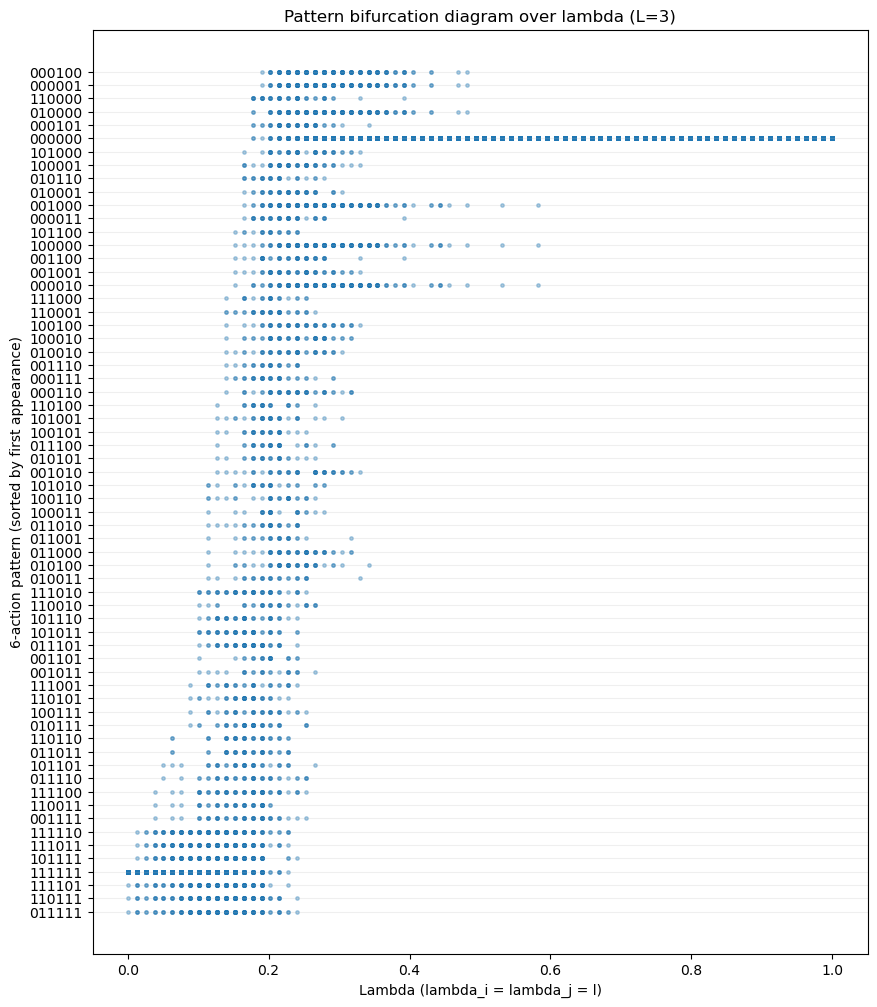

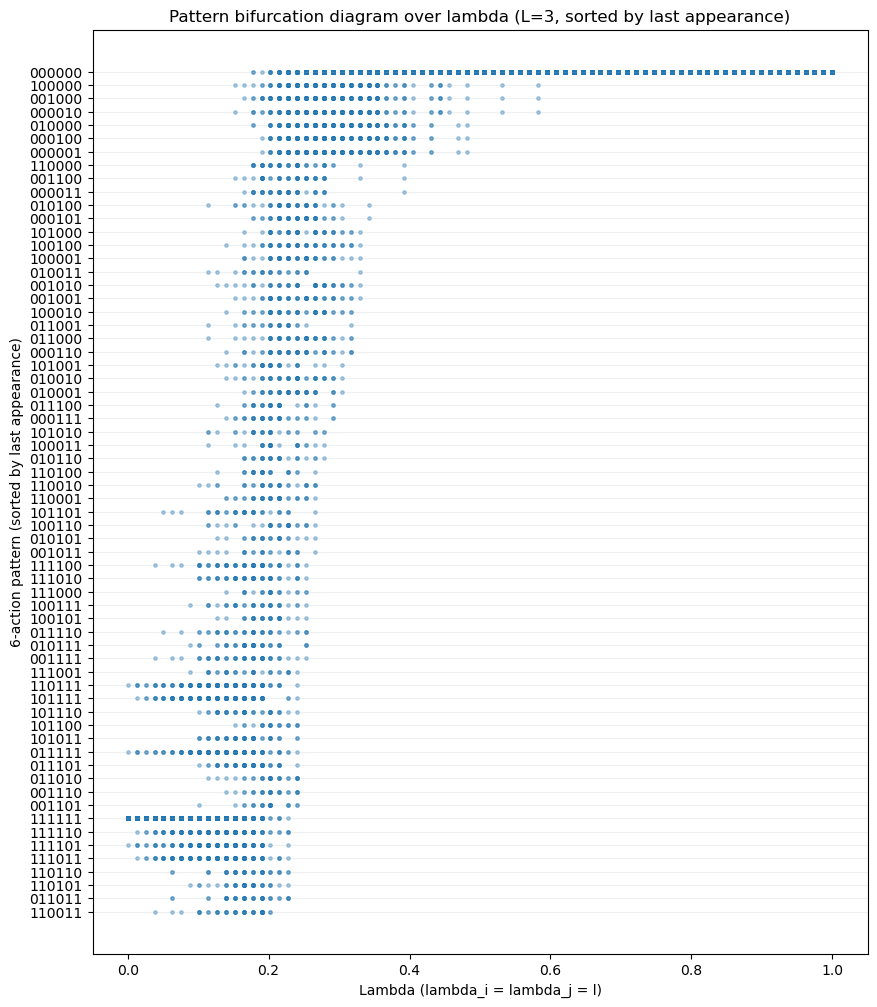

In [116]:

plt.figure(figsize=(10, 12))
plt.scatter(xs_arr, ys_transformed, s=6, alpha=0.35)
plt.xlabel("Lambda (lambda_i = lambda_j = l)")
plt.ylabel(f"{2*L}-action pattern (sorted by first appearance)")
plt.yticks(range(len(sorted_patterns)), [f"{p:0{2*L}b}" for p in sorted_patterns])
plt.title(f"Pattern bifurcation diagram over lambda (L={L})")
plt.grid(axis="y", alpha=0.2)
plt.show()

# Same plot but sorted by LAST appearance
# Find last appearance lambda for each pattern
last_appearance = {}
for pattern in unique_patterns:
    mask = ys_arr == pattern
    last_appearance[pattern] = xs_arr[mask].max()

# Sort patterns by last appearance
sorted_patterns_last = sorted(unique_patterns, key=lambda p: last_appearance[p])

# Create mapping from old pattern to new y-position
pattern_to_y_last = {pattern: idx for idx, pattern in enumerate(sorted_patterns_last)}

# Transform ys to new y-coordinates
ys_transformed_last = np.array([pattern_to_y_last[y] for y in ys_arr])

plt.figure(figsize=(10, 12))
plt.scatter(xs_arr, ys_transformed_last, s=6, alpha=0.35)
plt.xlabel("Lambda (lambda_i = lambda_j = l)")
plt.ylabel(f"{2*L}-action pattern (sorted by last appearance)")
plt.yticks(range(len(sorted_patterns_last)), [f"{p:0{2*L}b}" for p in sorted_patterns_last])
plt.title(f"Pattern bifurcation diagram over lambda (L={L}, sorted by last appearance)")
plt.grid(axis="y", alpha=0.2)
plt.show()

Computing trajectory for T =  300
Computing ensemble for lambda =  0.1
Computing ensemble for lambda =  0.1076923076923077
Computing ensemble for lambda =  0.11538461538461539
Computing ensemble for lambda =  0.12307692307692308
Computing ensemble for lambda =  0.13076923076923078
Computing ensemble for lambda =  0.13846153846153847
Computing ensemble for lambda =  0.14615384615384616
Computing ensemble for lambda =  0.15384615384615385
Computing ensemble for lambda =  0.16153846153846155
Computing ensemble for lambda =  0.16923076923076924
Computing ensemble for lambda =  0.17692307692307696
Computing ensemble for lambda =  0.18461538461538463
Computing ensemble for lambda =  0.19230769230769235
Computing ensemble for lambda =  0.2
Computing ensemble for lambda =  0.20769230769230773
Computing ensemble for lambda =  0.2153846153846154
Computing ensemble for lambda =  0.22307692307692312
Computing ensemble for lambda =  0.2307692307692308
Computing ensemble for lambda =  0.238461538461

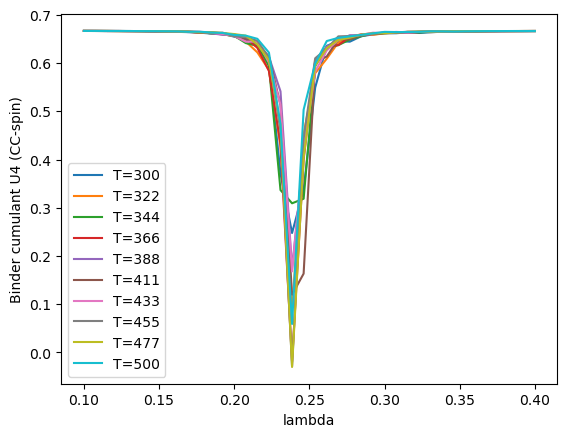

In [99]:
import numpy as np
import matplotlib.pyplot as plt

l_vals = np.linspace(0.1, 0.4, 40)

N_sizes = 10
sizes = np.linspace(300, 500, N_sizes, dtype=int)

R = 50          # runs per (lambda, size) - 10 is usually too noisy for Binder
burn_frac = 0.2 # discard first 20%

U = np.zeros((N_sizes, len(l_vals)))

for k, T in enumerate(sizes):
    burn = int(burn_frac * T)
    print("Computing trajectory for T = ", T)
    for j, lam in enumerate(l_vals):
        m = np.zeros(R)
        print("Computing ensemble for lambda = ", lam)
        for r in range(R):
            seed = np.random.randint(1_000_000_000)
            res = run_single_experiment(
                lam, lam, T=T, seed=seed, beta_i=5, beta_j=5, use_inversion=False
            )

            # CC indicator (your outcomes_num uses 0 for "CC")
            outcomes_arr = np.asarray(res.outcomes, dtype=int)
            s = (outcomes_arr[burn:] == 0).astype(float)

            # +/-1 spin derived from CC indicator
            spin = 2*s - 1
            m[r] = spin.mean()

        m2 = np.mean(m**2)
        m4 = np.mean(m**4)
        U[k, j] = 1.0 - m4 / (3.0 * (m2**2 + 1e-15))

for k, T in enumerate(sizes):
    plt.plot(l_vals, U[k, :], label=f"T={T}")
plt.xlabel("lambda")
plt.ylabel("Binder cumulant U4 (CC-spin)")
plt.legend()
plt.show()
